# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education. 

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms. 
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers, 
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn. 
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc 
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Problem definition

The objective is to predict the status column, which indicates whether a customer has converted (value 1) or not (value 0). This is a binary classification problem. The analysis will focus on understanding customer characteristics and interactions to identify patterns that influence conversion.

## Importing necessary libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score, confusion_matrix
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

plt.rcParams.update({'figure.max_open_warning': 0})

df = pd.read_csv("ExtraaLearn.csv")

## Data Overview

- Observations
- Sanity checks

In [2]:
print("Dataframe Shape")
df.shape

Dataframe Shape


(4612, 15)

The dataset contains 4612 unique records (potential customers/leads) and 15 different features or variables, including the target variable (status).

In [3]:
print("Data Description")
df.describe()

Data Description


,age,website_visits,time_spent_on_website,page_views_per_visit,status
count,4612.000000,4612.000000,4612.000000,4612.000000,4612.000000
mean,46.201214,3.566782,724.011275,3.026126,0.298569
std,13.161454,2.829134,743.828683,1.968125,0.457680
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,148.750000,2.077750,0.000000
50%,51.000000,3.000000,376.000000,2.792000,0.000000
75%,57.000000,5.000000,1336.750000,3.756250,1.000000
max,63.000000,30.000000,2537.000000,18.434000,1.000000


In [4]:
print("Columns:")
list(df.columns)

Columns:


['ID',
 'age',
 'current_occupation',
 'first_interaction',
 'profile_completed',
 'website_visits',
 'time_spent_on_website',
 'page_views_per_visit',
 'last_activity',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral',
 'status']

The dataset contains a set of features covering different aspects of a customer lead:
- Identifiers: ID
- Demographics: age, current_occupation
- Behavioral/Engagement: first_interaction, profile_completed, website_visits, time_spent_on_website, page_views_per_visit, last_activity
- Marketing/Channel: print_media_type1, print_media_type2, digital_media, educational_channels, referral
- Target variable: status

In [5]:
print("Column types:")
df.dtypes

Column types:


ID                        object
age                        int64
current_occupation        object
first_interaction         object
profile_completed         object
website_visits             int64
time_spent_on_website      int64
page_views_per_visit     float64
last_activity             object
print_media_type1         object
print_media_type2         object
digital_media             object
educational_channels      object
referral                  object
status                     int64
dtype: object

In [6]:
print("Top 5 rows:")
df.head()

Top 5 rows:


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [7]:
print("Last 5 rows:")
df.tail()

Last 5 rows:


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


The inspection of the first and last five rows gives an overview of the values in the columns:
- ID is a unique string identifier
- Categorical features (current_occupation, first_interaction, profile_completed, last_activity) contain descriptive strings
- Binary marketing features (print_media_type1, print_media_type2, digital_media, educational_channels, referral) use the values "Yes" and "No".
- The target variable (status) is represented as 1 or 0.

In [8]:
print("Existance of null values:")
df.isnull().sum()

Existance of null values:


ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

There are no missing values in any columns.

In [9]:
print("Existance of duplicated values:")
df.duplicated().sum()

Existance of duplicated values:


0

When considering every column, all 4612 records are unique.

In [10]:
df_copy = df.copy().drop(columns=['ID'])
print("Existance of duplicated values (No ID Column):")
df_copy.duplicated().sum()


Existance of duplicated values (No ID Column):


14

However, when the unique identificer column is excluded, 14 duplicated rows are present. This means that 14 pairs of records in the dataset share the exact same feature values.

From a predictive modeling perspective, these 14 redundant observations do not add unique information to the training set and can inflate the model's confidence in predicting for these specific feature combinations.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status? 
3. The company uses multiple modes to interact with prospects. Which way of interaction works best? 
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling 
- Any other preprocessing steps (if needed)

In [11]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))).sum()
    print(f"Outliers in {col}: {outliers}")

Outliers in age: 0
Outliers in website_visits: 154
Outliers in time_spent_on_website: 0
Outliers in page_views_per_visit: 257
Outliers in status: 0


The outlier analysis, performed using the Interquartile Range method, reveals that the features age and time_spent_on_website show no signs of outliers. Nevertheless, a significant presence of outliers was identified in website_visits (154) and page_views_per_visit (257). These exceptional values suggest the existance of a segment of customers who are unusally active or highly engaged with the platform.

In [12]:
df_copy = df.copy()
df_copy['status'].value_counts(normalize=True) * 100

0    70.143105
1    29.856895
Name: status, dtype: float64

The target variable status is imbalanced, with approximately 70% labeled as non-converted (0) and 30% as converted (1).  
This imbalance suggests the need for techniques such as class weighting, resampling, or threshold tuning during model training to avoid bias toward the majority class.

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [13]:
df.describe()

,age,website_visits,time_spent_on_website,page_views_per_visit,status
count,4612.000000,4612.000000,4612.000000,4612.000000,4612.000000
mean,46.201214,3.566782,724.011275,3.026126,0.298569
std,13.161454,2.829134,743.828683,1.968125,0.457680
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,148.750000,2.077750,0.000000
50%,51.000000,3.000000,376.000000,2.792000,0.000000
75%,57.000000,5.000000,1336.750000,3.756250,1.000000
max,63.000000,30.000000,2537.000000,18.434000,1.000000


In [14]:
#Categorical variables
print("Categorical variables: ")
categoricals = list(df.select_dtypes("object").columns)

print(categoricals)

#Values per column
for column in categoricals:
  print(df[column].name)
  print(df[column].value_counts())
  print("\n")

Categorical variables: 
['ID', 'current_occupation', 'first_interaction', 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']
ID
EXT001     1
EXT2884    1
EXT3080    1
EXT3079    1
EXT3078    1
          ..
EXT1537    1
EXT1536    1
EXT1535    1
EXT1534    1
EXT4612    1
Name: ID, Length: 4612, dtype: int64


current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: current_occupation, dtype: int64


first_interaction
Website       2542
Mobile App    2070
Name: first_interaction, dtype: int64


profile_completed
High      2264
Medium    2241
Low        107
Name: profile_completed, dtype: int64


last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: last_activity, dtype: int64


print_media_type1
No     4115
Yes     497
Name: print_media_type1, dtype: int64


print_media_type2
No     4379
Yes     233
Name: print_media_type2, dtype: int64

In [15]:
#Remove ID column and encode categorical variables
df_encoded = pd.get_dummies(df.drop(columns=['ID']))
df_encoded = df_encoded.drop_duplicates()

The ID column is a surrogate key, providing no analytical value or predictive power for the model, and should be dropped to simplify the dataset and avoid potential data leakage.

Once the non-analytical ID column has been removed, the dataset must be de-duplicated across all remaining feature columns. This process ensures that every row represents a unique observation based on the substantive data. Eliminating these redundant rows maintain data integrity, prevent over-representation, and avoid biasing any subsequent statistical analysis or machine learning model training.

In [16]:
df_encoded.columns

Index(['age', 'website_visits', 'time_spent_on_website',
       'page_views_per_visit', 'status', 'current_occupation_Professional',
       'current_occupation_Student', 'current_occupation_Unemployed',
       'first_interaction_Mobile App', 'first_interaction_Website',
       'profile_completed_High', 'profile_completed_Low',
       'profile_completed_Medium', 'last_activity_Email Activity',
       'last_activity_Phone Activity', 'last_activity_Website Activity',
       'print_media_type1_No', 'print_media_type1_Yes', 'print_media_type2_No',
       'print_media_type2_Yes', 'digital_media_No', 'digital_media_Yes',
       'educational_channels_No', 'educational_channels_Yes', 'referral_No',
       'referral_Yes'],
      dtype='object')

# Univariate Analysis

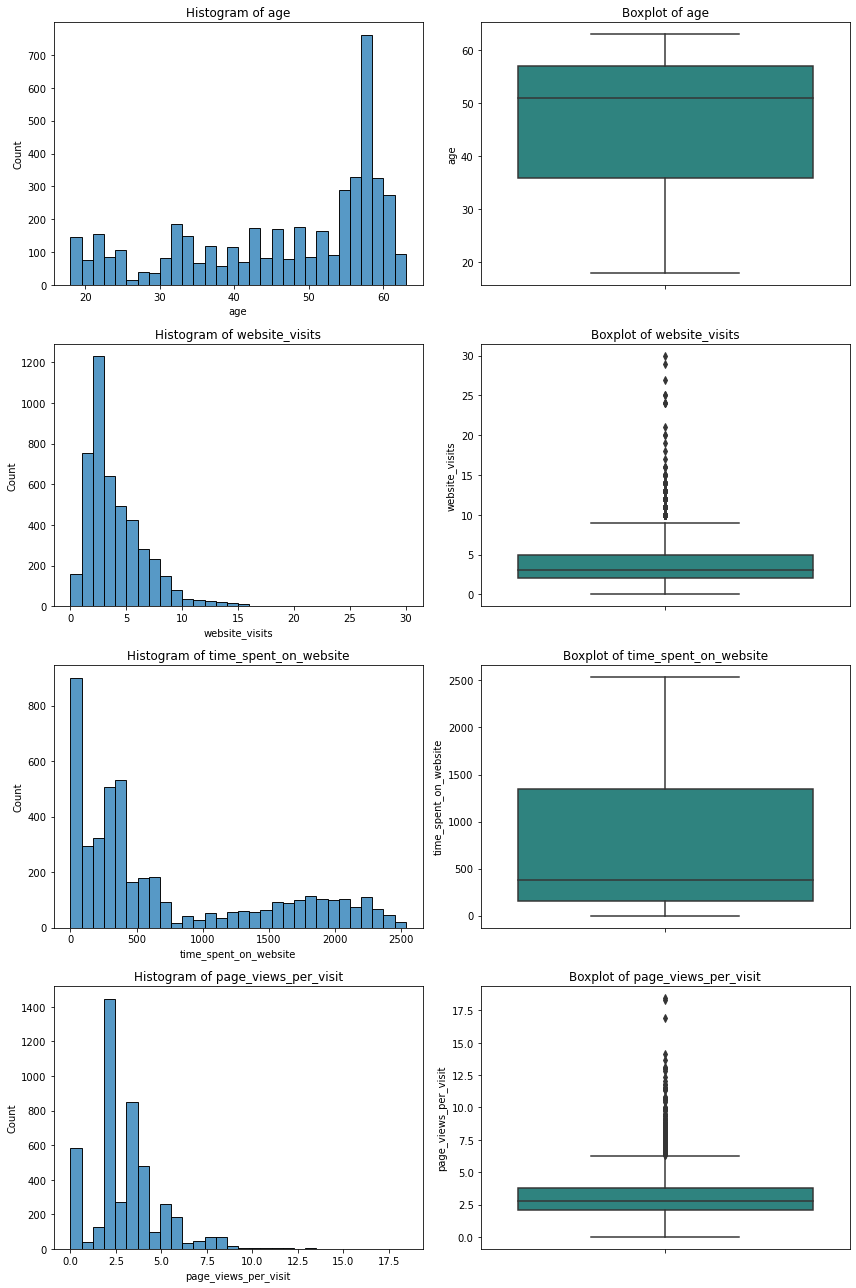

In [17]:
numeric_cols = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 18)) 

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_encoded, x=col, bins=30, ax=axes[i, 0], palette='viridis', kde=False)
    axes[i, 0].set_title(f"Histogram of {col}")

    sns.boxplot(y=df_encoded[col], ax=axes[i, 1], palette='viridis')
    axes[i, 1].set_title(f"Boxplot of {col}")
    axes[i, 1].set_ylabel(col)
    axes[i, 1].set_xlabel("")

plt.tight_layout()
plt.show()


The age distribution is not uniform. There are several peaks — one around ages 20–30, another scattered zone between 30–50, and a significant rise between 55–60. This indicates a high concentration of older users (50+). The interquartile range lies mainly between 45 and 60. There are few extreme values, so the distribution is relatively stable with no major outliers.

The website_visits variable distribution is heavily right-skewed. Most users make 1–5 visits, while only a few exceed 15. There are numerous outliers above the upper whisker (over 10-15 visits). The median is low (around 4), meaning a small group of highly active users compared to a majority with few visits.

The time_spent_on_website variable is also right-skewed, with several intermediate peaks. Most users spend less than 500 seconds (around 8 minutes), but some exceed 2000 seconds (around 33 minutes). There is a wide interquartile range and some high outliers, indicating large variability in browsing time (possibly a key indicator of engagement or conversion likelihood).

The page_views_per_visit variable is strongly right-skewed, with most users viewing 1–3 pages per visit. Only a few exceed 10 pages. The boxplot chart displays many high outliers (>7 pages/visit), though the median is between 2 and 3. This suggests a small segment of users deeply exploring the site.

All four numerical variables show non-normal, positively skewed distributions. The behavioral metrics (website_visits, time_spent_on_website, page_views_per_visit) exhibit a common pattern, a small fraction of very active users and a majority with low activity. This contrast is likely key for predicting status, as active users may follow a distinct conversion pattern.

In [18]:
cat_cols = df_encoded.select_dtypes(include='uint8').columns.tolist()
cat_cols

['current_occupation_Professional',
 'current_occupation_Student',
 'current_occupation_Unemployed',
 'first_interaction_Mobile App',
 'first_interaction_Website',
 'profile_completed_High',
 'profile_completed_Low',
 'profile_completed_Medium',
 'last_activity_Email Activity',
 'last_activity_Phone Activity',
 'last_activity_Website Activity',
 'print_media_type1_No',
 'print_media_type1_Yes',
 'print_media_type2_No',
 'print_media_type2_Yes',
 'digital_media_No',
 'digital_media_Yes',
 'educational_channels_No',
 'educational_channels_Yes',
 'referral_No',
 'referral_Yes']

In [19]:
occupation_cols = [col for col in df_encoded.columns if col.startswith('current_occupation_')]
interaction_cols = [col for col in df_encoded.columns if col.startswith('first_interaction_')]
profile_cols = [col for col in df_encoded.columns if col.startswith('profile_completed_')]
activity_cols = [col for col in df_encoded.columns if col.startswith('last_activity_')]

#Media channels grouped together
media_cols = [
    col for col in df_encoded.columns
    if col.startswith(('print_media_type', 'digital_media_', 'educational_channels_', 'referral_'))
]

grouped_cat_cols = {
    "Occupation": occupation_cols,
    "First Interaction": interaction_cols,
    "Profile Completion": profile_cols,
    "Last Activity": activity_cols,
    "Media Channels": media_cols
}

grouped_cat_cols


{'Occupation': ['current_occupation_Professional',
  'current_occupation_Student',
  'current_occupation_Unemployed'],
 'First Interaction': ['first_interaction_Mobile App',
  'first_interaction_Website'],
 'Profile Completion': ['profile_completed_High',
  'profile_completed_Low',
  'profile_completed_Medium'],
 'Last Activity': ['last_activity_Email Activity',
  'last_activity_Phone Activity',
  'last_activity_Website Activity'],
 'Media Channels': ['print_media_type1_No',
  'print_media_type1_Yes',
  'print_media_type2_No',
  'print_media_type2_Yes',
  'digital_media_No',
  'digital_media_Yes',
  'educational_channels_No',
  'educational_channels_Yes',
  'referral_No',
  'referral_Yes']}

In [20]:
#Function defined to plot each group of categorical columns
def plot_categorical_group(group_name, df, grouped_cols_dict):
  cols = grouped_cols_dict[group_name]

  fig, axes = plt.subplots(
    nrows=len(cols),
    ncols=1,
    figsize=(10, 5 * len(cols))
  )

  if len(cols) == 1:
    axes = [axes]

  for i, col in enumerate(cols):
    ax = axes[i]
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=0)

    for container in ax.containers:
      ax.bar_label(container, padding=3)

  plt.tight_layout()
  plt.show()

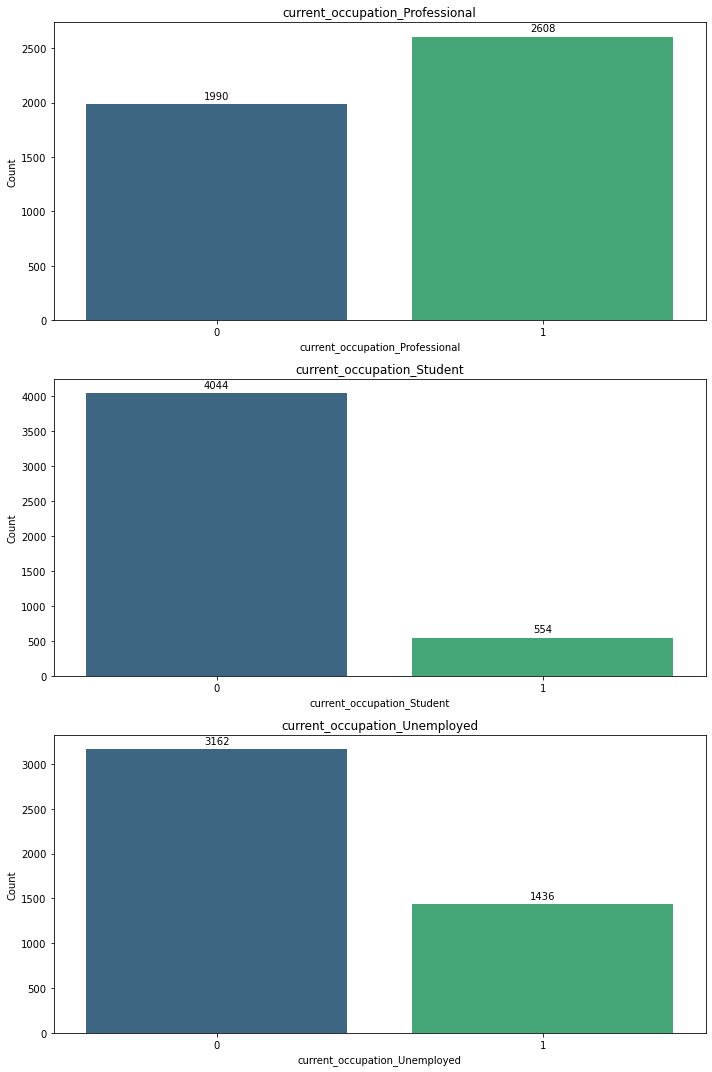

In [21]:
plot_categorical_group("Occupation", df_encoded, grouped_cat_cols)

There are 2,608 professionals (value 1) and 1,990 non-professionals (value 0) in the dataset. Students represent a relatively small share of the sample (around 12%), indicating limited presence within the overall audience. Meanwhile, unemployed users account for approximately 31%, which, although not the majority, still represents a notable segment that may show distinct browsing or engagement patterns.

Overall, professionals form a slight majority. This suggests that more than half of the users are likely individuals with stable employment and potentially higher purchasing power, shaping the platform’s primary audience profile.

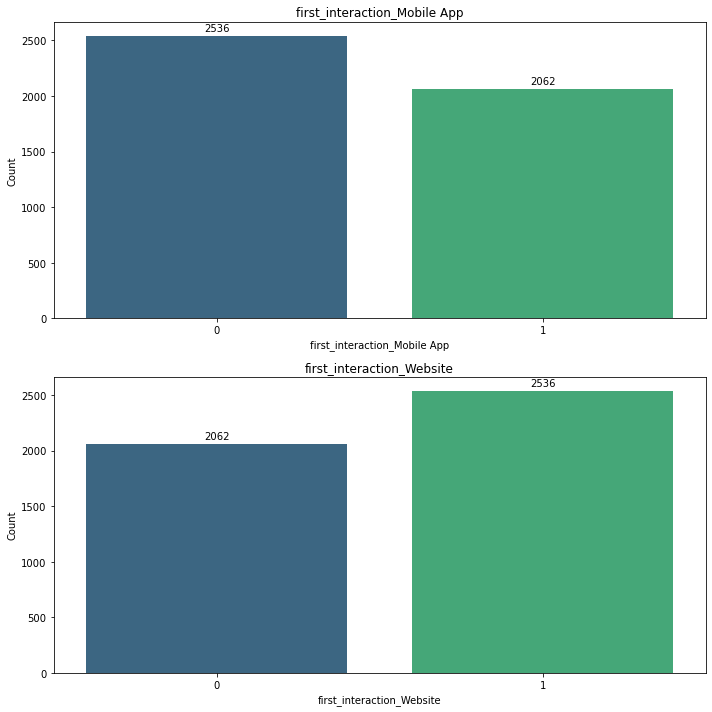

In [22]:
plot_categorical_group("First Interaction", df_encoded, grouped_cat_cols)

There are 2,062 users who interacted via the mobile app and 2,536 users who interacted through the website. This distribution shows that website interactions are slightly more common, representing a larger share of the total audience. Mobile app interactions still account for a substantial proportion of users, indicating that the app is actively used and serves as an important engagement channel. Users who choose the mobile app may exhibit different behavioral patterns, such as more frequent but shorter sessions, depending on the design and convenience of the app environment. On the other hand, the website remains the dominant interaction channel, capturing over half of the total interactions. This could suggest stronger discoverability via browsers, preference for larger-screen navigation, or that certain features or content are more accessible or visible through the website interface.

The presence of both channels with relatively strong usage suggests a multi-platform audience. This may influence platform optimization strategies, slightly prioritizing website performance while continuing to support and improve the mobile app experience.

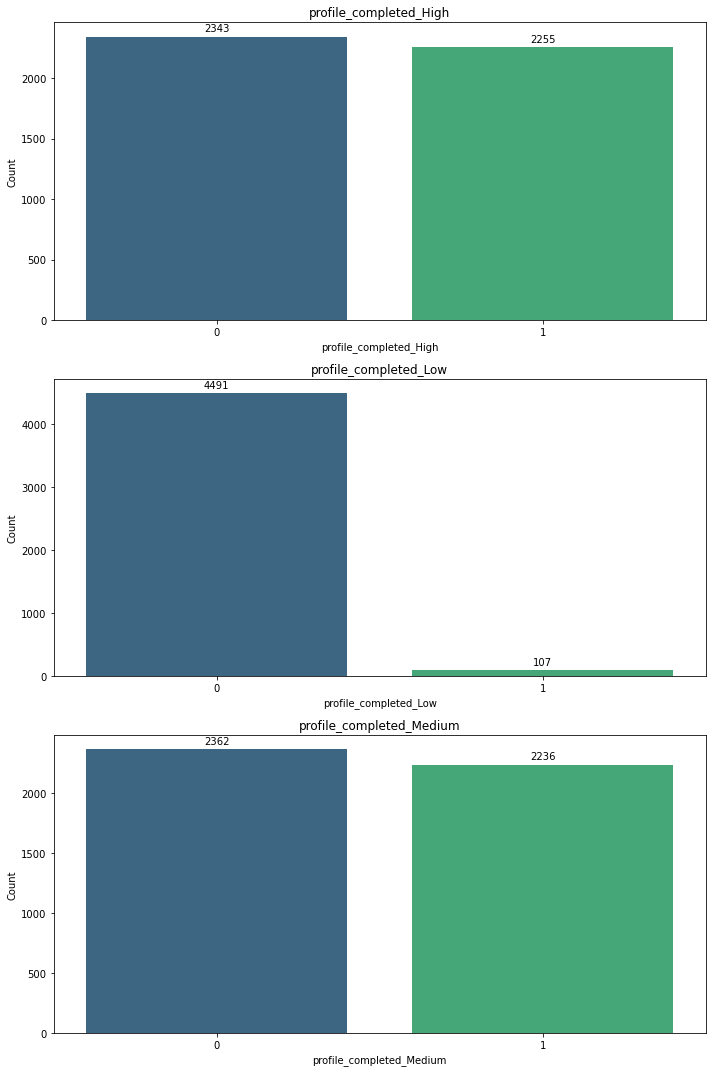

In [23]:
plot_categorical_group("Profile Completion", df_encoded, grouped_cat_cols)

There are 2,255 users with a high level of profile completion, 2,236 users with a medium level, and only 107 users with a low level of completion. This distribution reveals a strong tendency toward well-completed profiles, with the vast majority of users having provided substantial information about themselves on the platform.

The nearly even balance between high and medium completion levels suggests that most users are actively engaged and willing to share details, possibly reflecting trust in the platform and interest in receiving more personalized recommendations or interactions. These users likely demonstrate greater activity and retention potential, as a more complete profile often correlates with stronger engagement and relevance of the offered content.

In contrast, the small proportion of low-completion profiles (around 2%) indicates that only a minor fraction of users have provided minimal information. This group may represent either new users still in the onboarding process or less engaged individuals who have not yet interacted deeply with the platform.

The data shows that the platform’s audience is largely composed of users with medium to high profile completeness, which is a positive indicator of user quality and engagement. Maintaining this high level of completeness — while encouraging the small low-completion group to update their profiles — could further enhance personalization, recommendation accuracy, and user satisfaction.

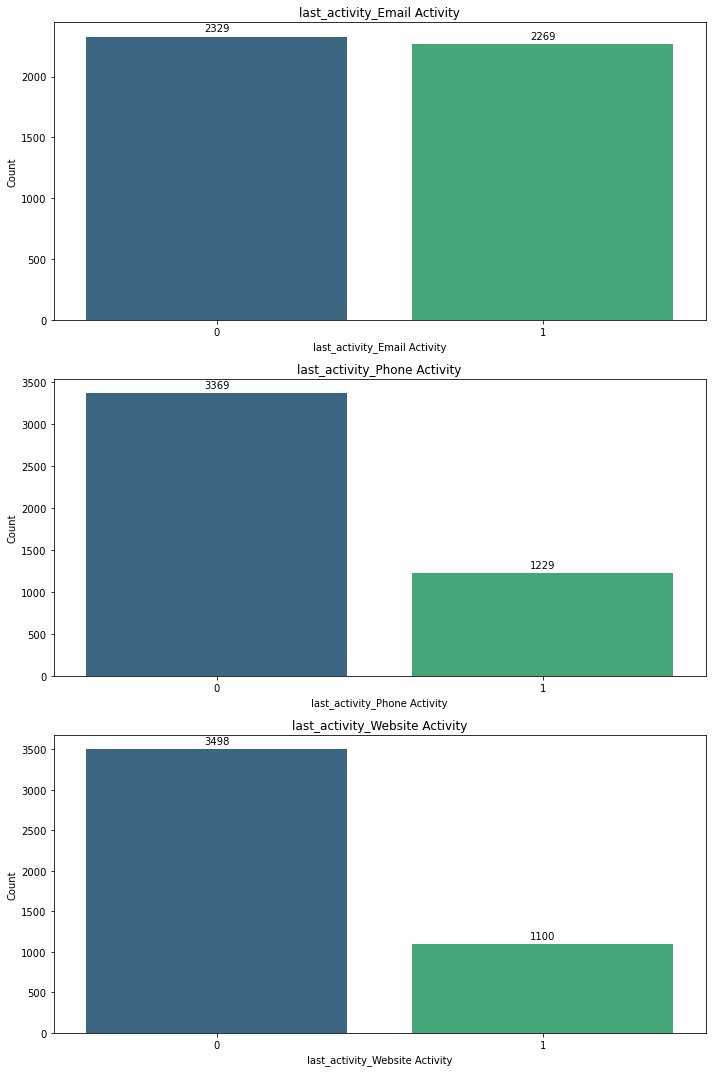

In [24]:
plot_categorical_group("Last Activity", df_encoded, grouped_cat_cols)

There are 2,269 users whose last recorded activity was through email, 1,229 users who last interacted via phone, and 1,100 users whose most recent activity occurred on the website. This distribution shows that email remains the dominant communication and engagement channel, accounting for the largest portion of user activity within the dataset.

The strong presence of email interactions suggests that users are more responsive or engaged through asynchronous communication, possibly indicating that email campaigns, newsletters, or personalized messages are effective in maintaining user contact. This could also reflect the platform’s reliance on email as the primary mode for updates, promotions, or reminders.

Phone interactions, representing the second most frequent activity type, demonstrate a meaningful level of direct engagement. This group of users might prefer more personalized or immediate contact methods, such as customer support or direct sales follow-ups. Their inclusion points to a user segment that values direct communication, potentially associated with higher conversion or retention rates.

Website-based activity, while the least frequent among the three, still involves over 1,100 users, reflecting continued interaction through the platform’s digital interface. These users may rely on self-service options, browsing, or content consumption rather than direct communication.

Taken together, the data indicates that email is the platform’s primary engagement driver, followed by phone and website activities.

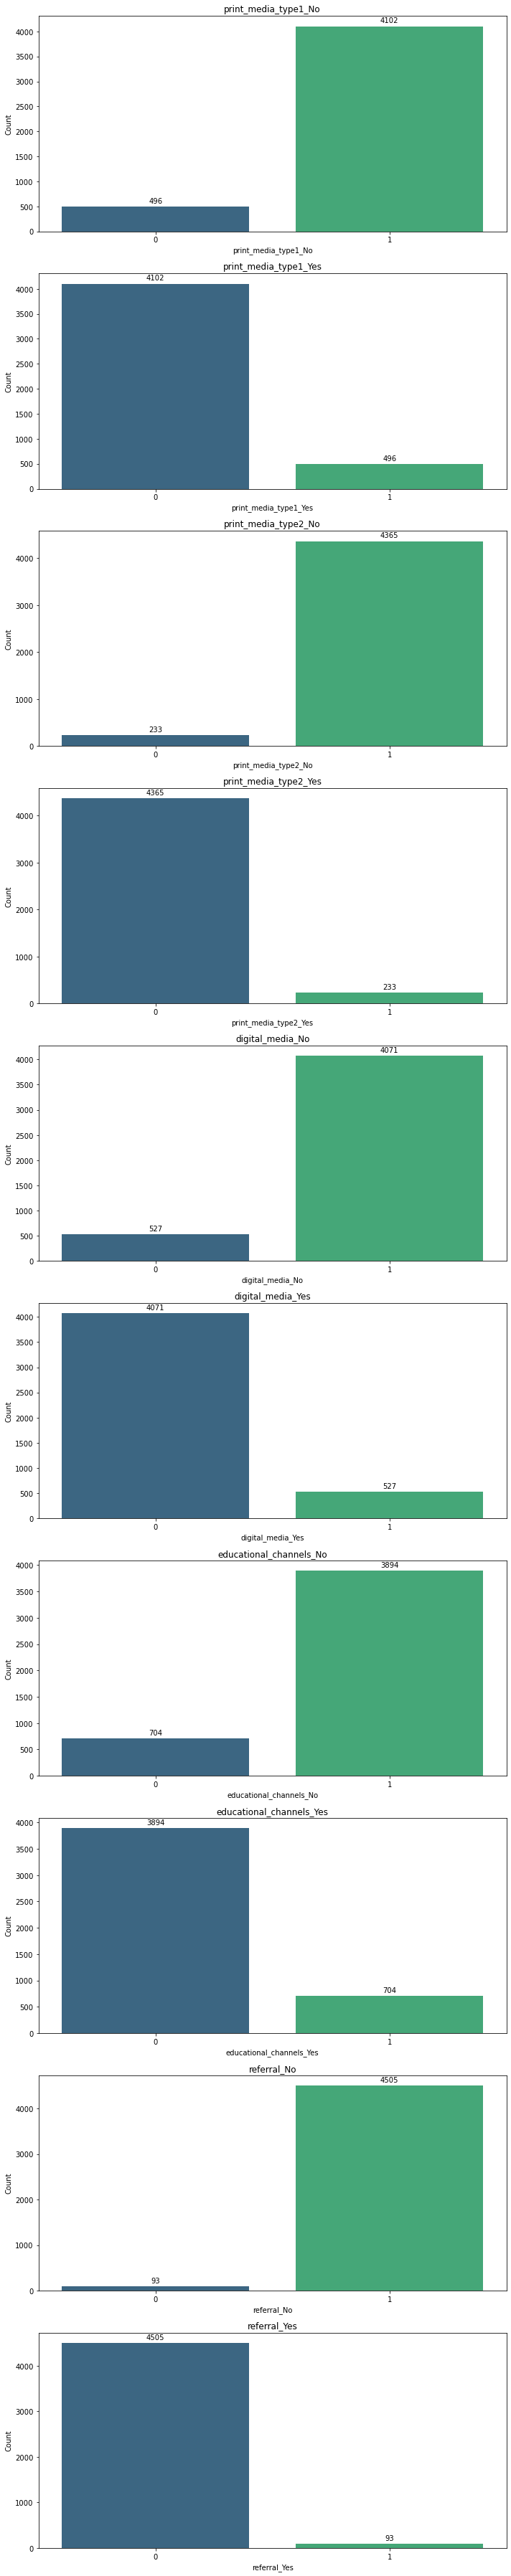

In [25]:
plot_categorical_group("Media Channels", df_encoded, grouped_cat_cols)

There are 496 users who learned about ExtraaLearn through newspaper ads, 233 through magazine ads, 527 via digital media, 704 through educational channels, and 93 through referrals.

This distribution indicates that educational channels serve as the most influential source of awareness. Digital media follows closely as the second most effective medium. Print media—including both newspapers and magazines—plays a smaller role. Referrals represent the smallest share.

# Bivariate Analysis

The following bivariate analysis will focus on examining the relationships between the 'status' variable and the other attributes in the dataset. This approach helps identify patterns and significant associations that may explain the factors influencing lead conversion within the platform. By exploring these relationships, the goal is to determine which characteristics are most closely linked to the final user status, thus providing key insights to guide marketing strategies and optimize the customer acquisition process.

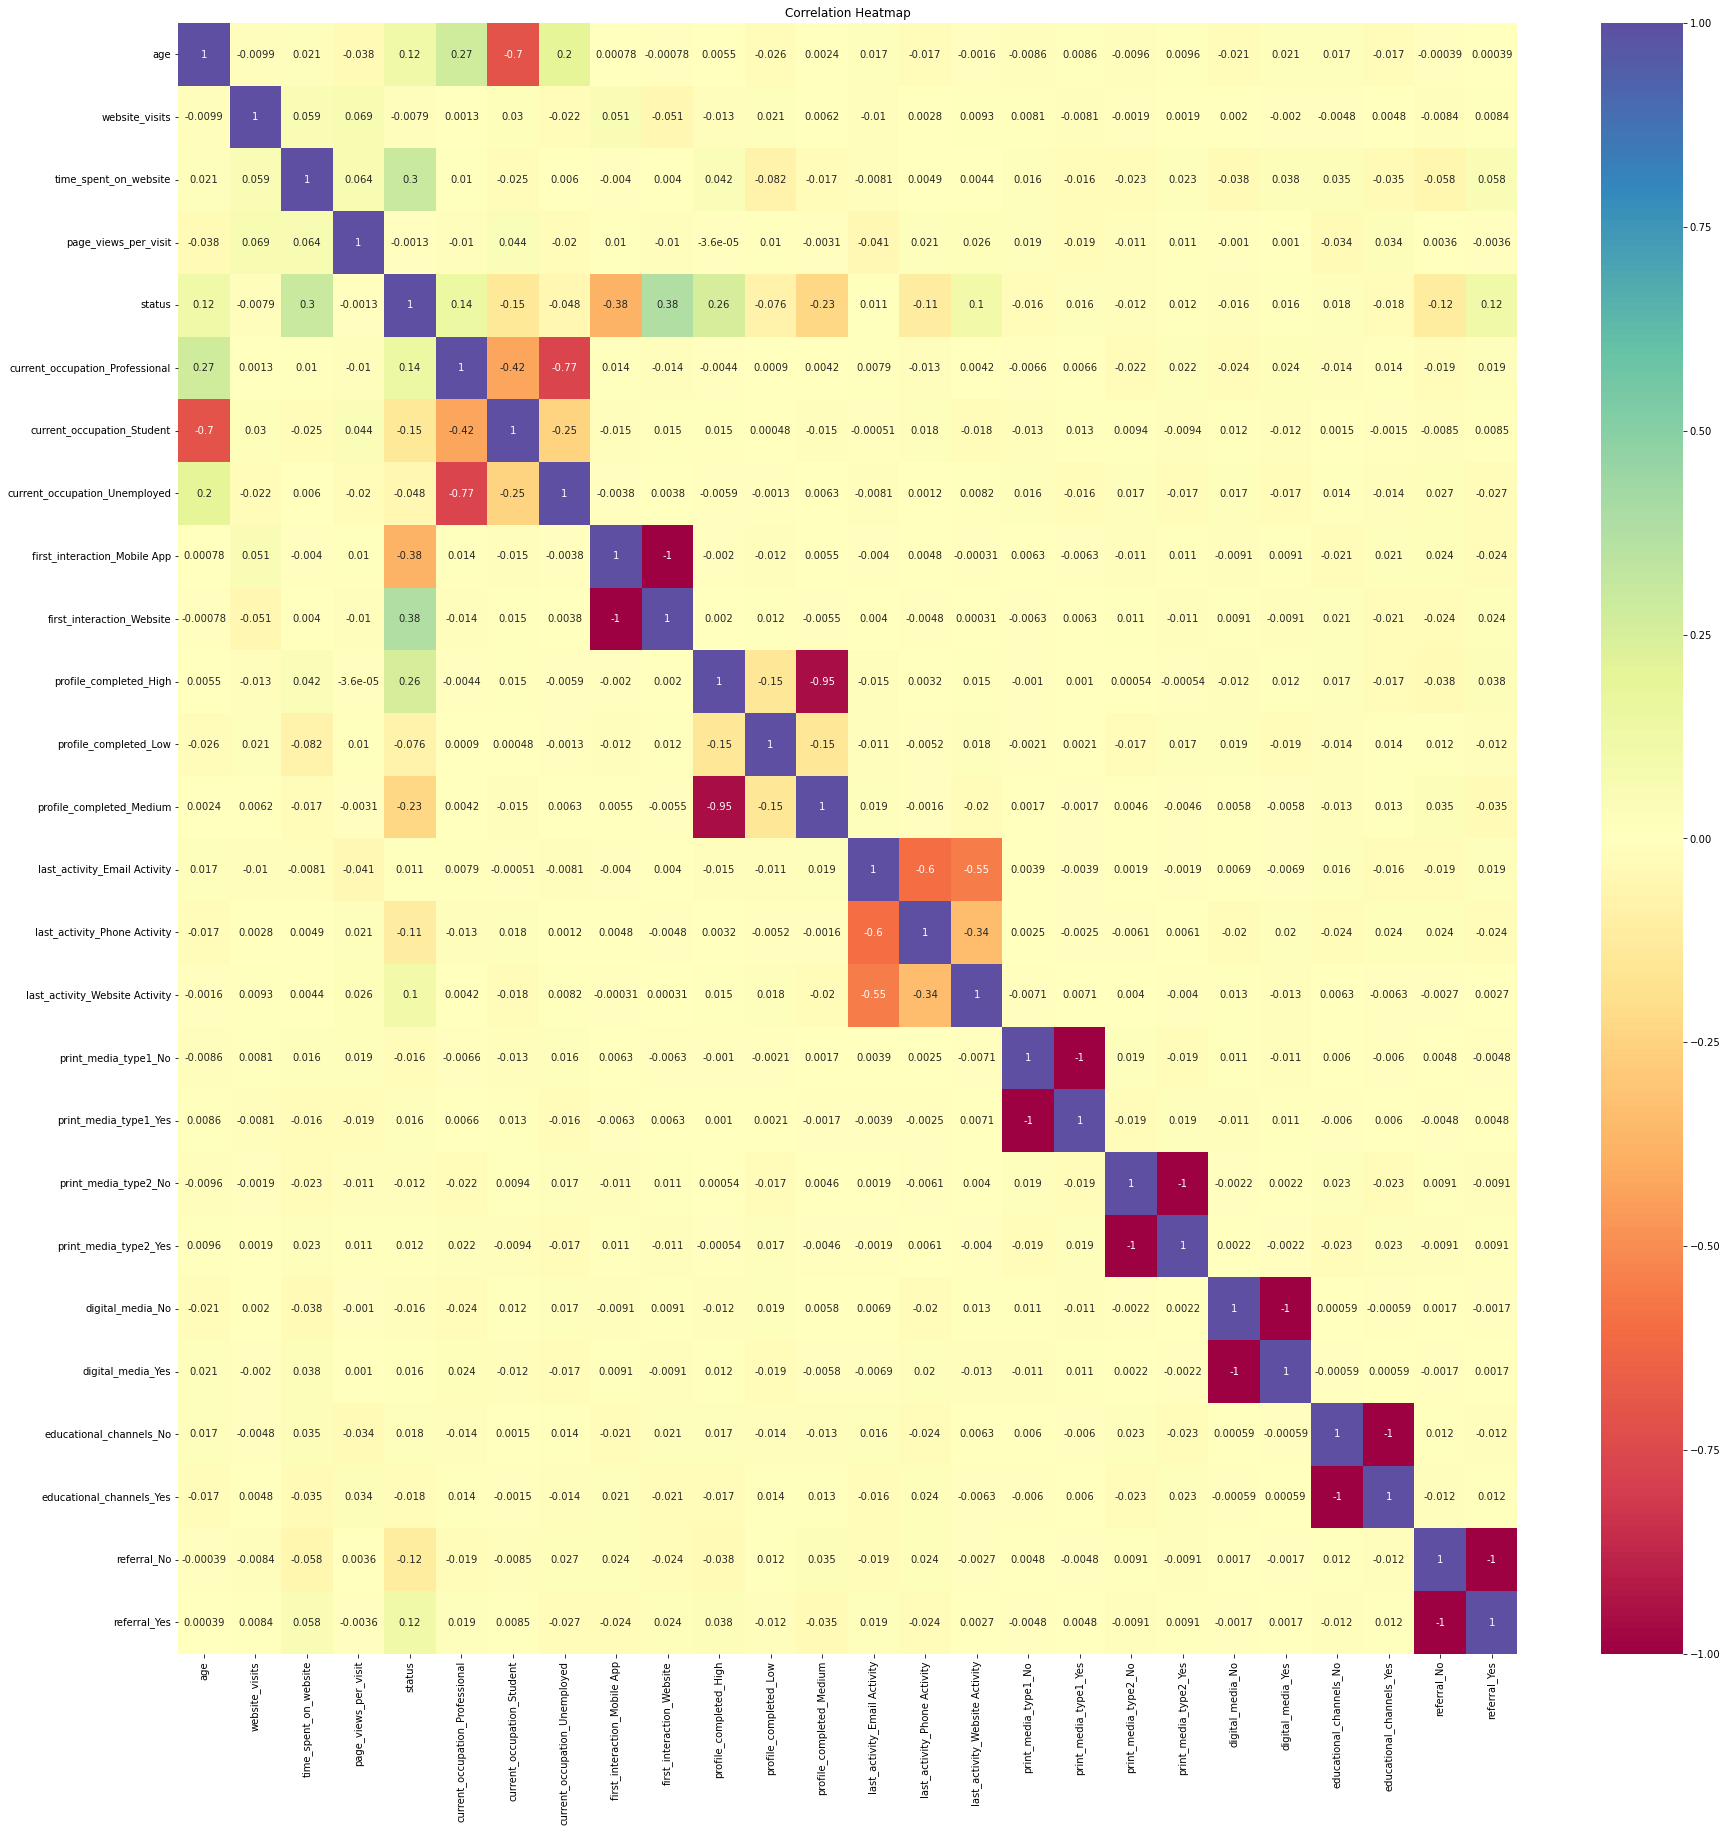

In [ ]:
plt.figure(figsize=(30, 30))
sns.heatmap(df_encoded.corr(), annot=True, cmap="Spectral", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


In [27]:
def distribution_plot_wrt_target(data, predictor, target="status", palette="viridis"):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    sns.kdeplot(
        data=data, x=predictor, hue=target, fill=True, ax=axs[0], palette=palette
    )
    axs[0].set_title(f"{predictor}: Distribution by {target}")

    sns.boxplot(
        data=data, x=target, y=predictor, ax=axs[1], palette=palette
    )
    axs[1].set_title(f"{predictor}: Boxplot by {target}")

    plt.tight_layout()
    plt.show()


def stacked_barplot(data, predictor, target="status"):
    tab = pd.crosstab(data[predictor], data[target], normalize="index")
    tab.plot(kind="bar", stacked=True, figsize=(8, 4))
    plt.title(f"{predictor} vs {target}")
    plt.ylabel("Proportion")
    plt.legend(["Not Converted", "Converted"])
    plt.show()


In [28]:
def distribution_plot_wrt_target(data, predictor, target="status", palette="viridis"):
    #Numerical Summary Table
    summary_stats = data.groupby(target)[predictor].describe()
    print(f"\nNumerical Summary for '{predictor}' by '{target}':\n")
    display(summary_stats)

    #Plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    sns.kdeplot(
        data=data, x=predictor, hue=target, fill=True, ax=axs[0], palette=palette
    )
    axs[0].set_title(f"{predictor}: Distribution by {target}")

    sns.boxplot(
        data=data, x=target, y=predictor, ax=axs[1], palette=palette
    )
    axs[1].set_title(f"{predictor}: Boxplot by {target}")

    plt.tight_layout()
    plt.show()


def stacked_barplot(data, predictor, target="status", palette="viridis"):
    #Crosstab Tables
    abs_counts = pd.crosstab(data[predictor], data[target])
    pct_counts = pd.crosstab(data[predictor], data[target], normalize="index") * 100

    print(f"\nFrequency Table for '{predictor}' vs '{target}':\n")
    display(abs_counts)

    print(f"\nPercentage Table for '{predictor}' vs '{target}':\n")
    display(pct_counts.round(2))

    #Plot
    plt.figure(figsize=(8, 4))
    
    pct_melted = pct_counts.reset_index().melt(id_vars=predictor, var_name=target, value_name='percentage')
    
    sns.barplot(data=pct_melted, x=predictor, y='percentage', hue=target, palette=palette)
    
    plt.title(f"{predictor} vs {target} (Stacked %)")
    plt.ylabel("Percentage (%)")
    plt.legend(title=target)
    
    plt.tight_layout()
    plt.show()


Numerical Summary for 'age' by 'status':



,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
0,3223.0,45.125349,13.747652,18.0,33.0,49.0,57.0,63.0
1,1375.0,48.649455,11.295651,18.0,41.0,54.0,58.0,63.0


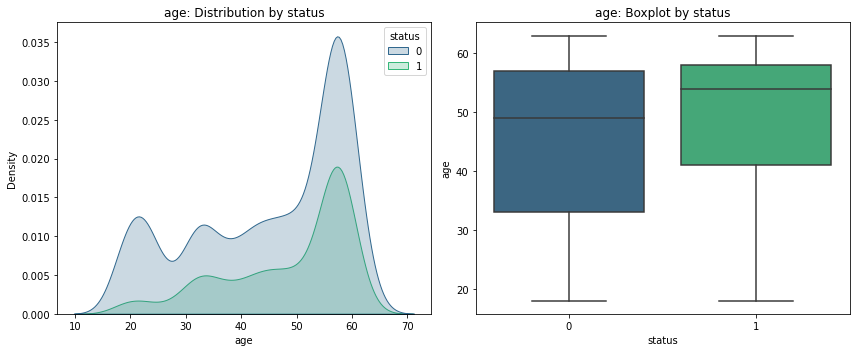


Numerical Summary for 'website_visits' by 'status':



,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
0,3223.0,3.592305,2.871243,0.0,2.0,3.0,5.0,30.0
1,1375.0,3.543273,2.719702,0.0,2.0,3.0,5.0,25.0


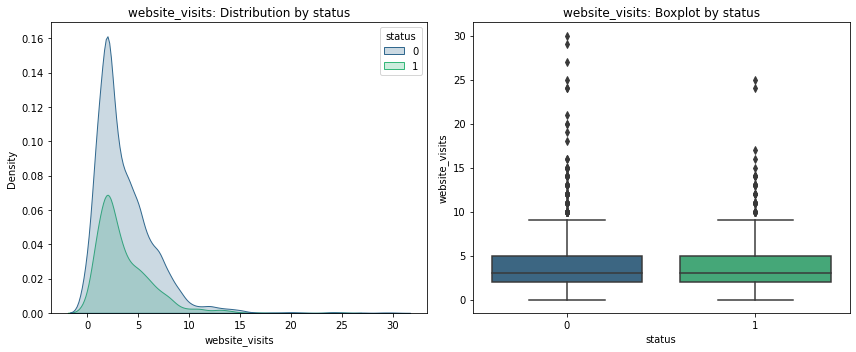


Numerical Summary for 'page_views_per_visit' by 'status':



,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
0,3223.0,3.036998,1.993112,0.0,2.0780,2.752,3.7745,18.434
1,1375.0,3.031453,1.894751,0.0,2.0855,2.937,3.7300,13.656


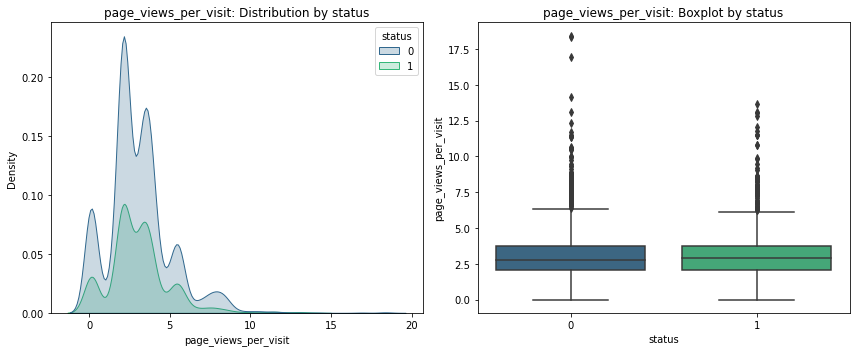


Numerical Summary for 'time_spent_on_website' by 'status':



,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
0,3223.0,579.570586,676.678457,0.0,89.5,317.0,648.5,2531.0
1,1375.0,1069.952000,780.359329,0.0,391.0,798.0,1830.5,2537.0


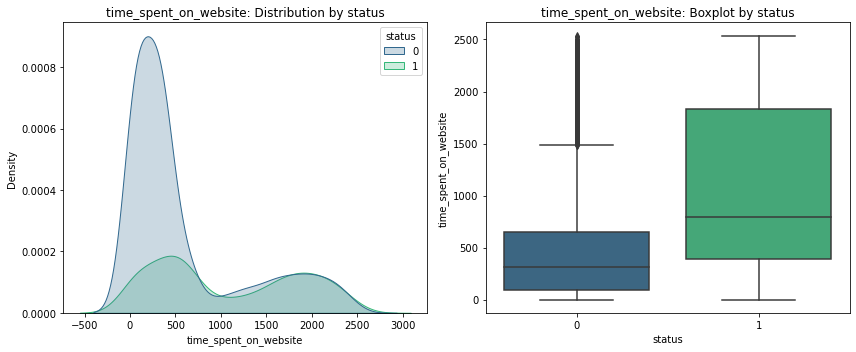

In [29]:
distribution_plot_wrt_target(df_encoded, "age", "status")
distribution_plot_wrt_target(df_encoded, "website_visits", "status")
distribution_plot_wrt_target(df_encoded, "page_views_per_visit", "status")
distribution_plot_wrt_target(df_encoded, "time_spent_on_website", "status")


Age shows a meaningful difference: users with status = 1 have an average age of 48.65 years, compared to 45.13 years for status = 0, a difference of approximately 3.52 years. The median age also rises from 49 to 54. This suggests that converted users (status = 1) are systematically older. Their distribution is also tighter, with a lower standard deviation (11.30 vs. 13.75), indicating less variability among converters.

For website_visits, the means are nearly identical: 3.59 for non-converters versus 3.54 for converters. Medians are the same (3), and quartiles align closely (Q1 = 2, Q3 = 5). The standard deviation is slightly lower among converters (2.72 vs. 2.87). This indicates that the number of visits alone does not strongly distinguish between the two groups. While there are outliers—with maximum values of 30 and 25 visits, representing a few highly active users—the central mass of the distributions is similar.

In the case of page_views_per_visit, the mean difference is negligible (approximately 3.037 vs. 3.031), and medians (2.75 vs. 2.94) show only a minor shift. Dispersion is slightly lower for converters (std 1.89 vs. 1.99), and non-converters reach higher maximum values, suggesting that some non-converters explore more pages per visit.

The most notable finding concerns time_spent_on_website variable. The mean for status = 1 is 1069.95 seconds, compared to 579.57 seconds for status = 0, a difference of approximately 490 seconds (about 8.2 minutes). The medians reflect this trend (798 s vs. 317 s, a difference of approximately 481 seconds). Moreover, variability and IQR are considerably larger for status = 1 (IQR 1,439.5 s vs. 559 s), indicating that while converters generally spend more time on the platform, there is also greater heterogeneity within this group, with some users spending extremely long sessions (up to ~2537 seconds).


Frequency Table for 'current_occupation_Professional' vs 'status':



status,0,1
current_occupation_Professional,,
0,1542,448
1,1681,927



Percentage Table for 'current_occupation_Professional' vs 'status':



status,0,1
current_occupation_Professional,,
0,77.49,22.51
1,64.46,35.54


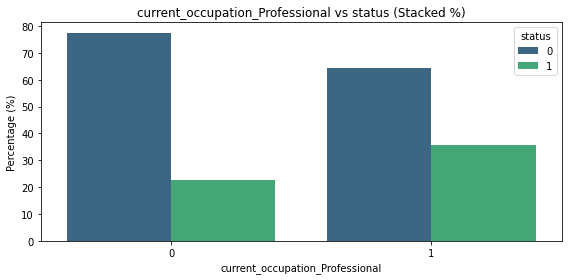


Frequency Table for 'current_occupation_Student' vs 'status':



status,0,1
current_occupation_Student,,
0,2734,1310
1,489,65



Percentage Table for 'current_occupation_Student' vs 'status':



status,0,1
current_occupation_Student,,
0,67.61,32.39
1,88.27,11.73


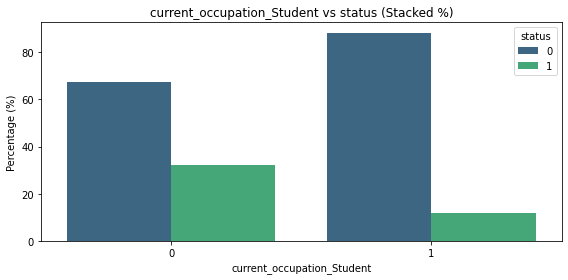


Frequency Table for 'current_occupation_Unemployed' vs 'status':



status,0,1
current_occupation_Unemployed,,
0,2170,992
1,1053,383



Percentage Table for 'current_occupation_Unemployed' vs 'status':



status,0,1
current_occupation_Unemployed,,
0,68.63,31.37
1,73.33,26.67


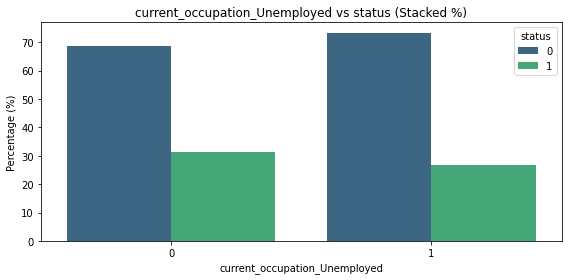


Frequency Table for 'first_interaction_Mobile App' vs 'status':



status,0,1
first_interaction_Mobile App,,
0,1379,1157
1,1844,218



Percentage Table for 'first_interaction_Mobile App' vs 'status':



status,0,1
first_interaction_Mobile App,,
0,54.38,45.62
1,89.43,10.57


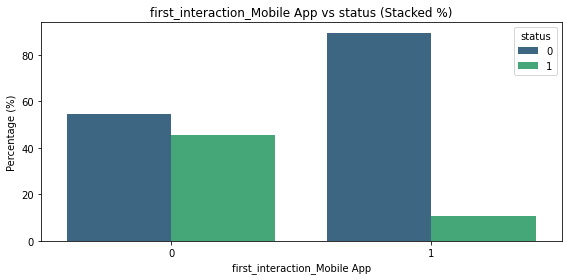


Frequency Table for 'first_interaction_Website' vs 'status':



status,0,1
first_interaction_Website,,
0,1844,218
1,1379,1157



Percentage Table for 'first_interaction_Website' vs 'status':



status,0,1
first_interaction_Website,,
0,89.43,10.57
1,54.38,45.62


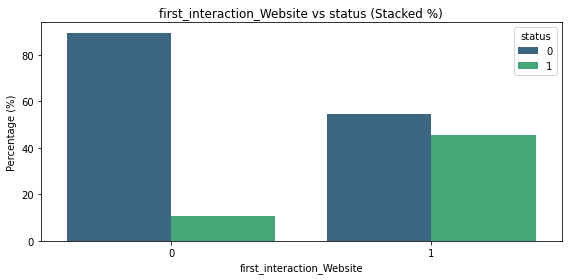


Frequency Table for 'profile_completed_High' vs 'status':



status,0,1
profile_completed_High,,
0,1912,431
1,1311,944



Percentage Table for 'profile_completed_High' vs 'status':



status,0,1
profile_completed_High,,
0,81.60,18.40
1,58.14,41.86


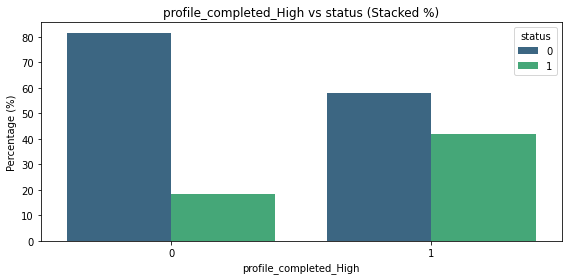


Frequency Table for 'profile_completed_Low' vs 'status':



status,0,1
profile_completed_Low,,
0,3124,1367
1,99,8



Percentage Table for 'profile_completed_Low' vs 'status':



status,0,1
profile_completed_Low,,
0,69.56,30.44
1,92.52,7.48


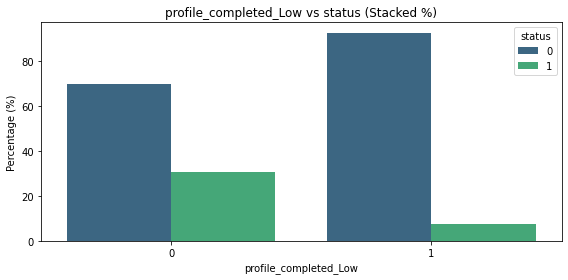


Frequency Table for 'profile_completed_Medium' vs 'status':



status,0,1
profile_completed_Medium,,
0,1410,952
1,1813,423



Percentage Table for 'profile_completed_Medium' vs 'status':



status,0,1
profile_completed_Medium,,
0,59.70,40.30
1,81.08,18.92


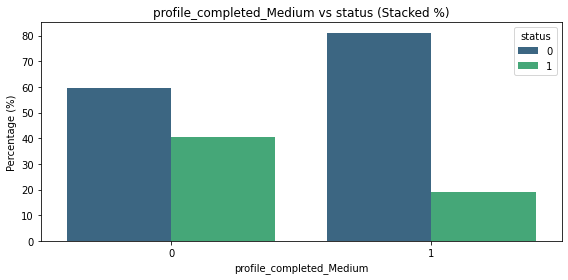


Frequency Table for 'last_activity_Email Activity' vs 'status':



status,0,1
last_activity_Email Activity,,
0,1644,685
1,1579,690



Percentage Table for 'last_activity_Email Activity' vs 'status':



status,0,1
last_activity_Email Activity,,
0,70.59,29.41
1,69.59,30.41


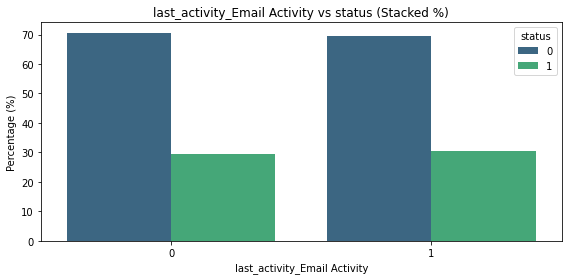


Frequency Table for 'last_activity_Phone Activity' vs 'status':



status,0,1
last_activity_Phone Activity,,
0,2256,1113
1,967,262



Percentage Table for 'last_activity_Phone Activity' vs 'status':



status,0,1
last_activity_Phone Activity,,
0,66.96,33.04
1,78.68,21.32


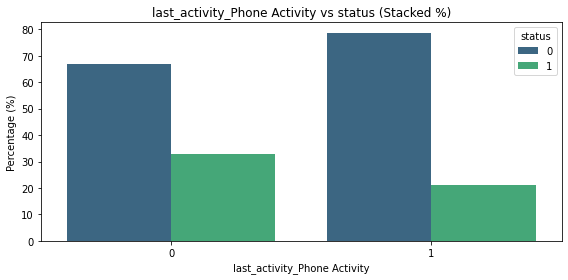


Frequency Table for 'last_activity_Website Activity' vs 'status':



status,0,1
last_activity_Website Activity,,
0,2546,952
1,677,423



Percentage Table for 'last_activity_Website Activity' vs 'status':



status,0,1
last_activity_Website Activity,,
0,72.78,27.22
1,61.55,38.45


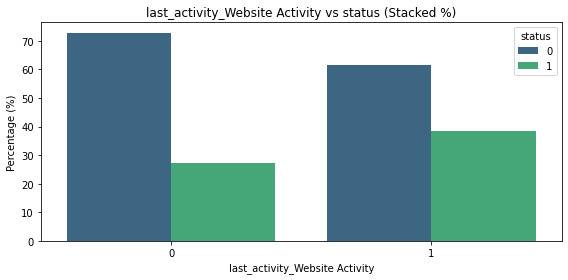


Frequency Table for 'print_media_type1_No' vs 'status':



status,0,1
print_media_type1_No,,
0,337,159
1,2886,1216



Percentage Table for 'print_media_type1_No' vs 'status':



status,0,1
print_media_type1_No,,
0,67.94,32.06
1,70.36,29.64


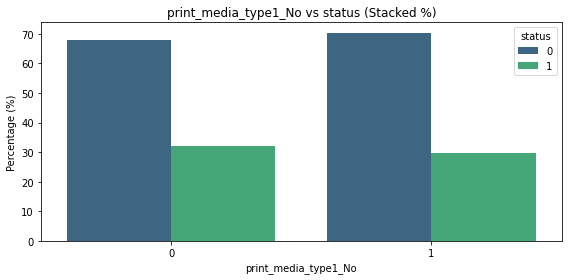


Frequency Table for 'print_media_type1_Yes' vs 'status':



status,0,1
print_media_type1_Yes,,
0,2886,1216
1,337,159



Percentage Table for 'print_media_type1_Yes' vs 'status':



status,0,1
print_media_type1_Yes,,
0,70.36,29.64
1,67.94,32.06


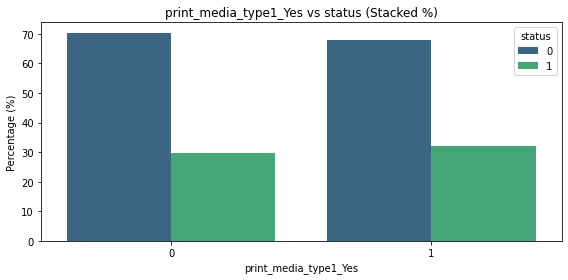


Frequency Table for 'print_media_type2_No' vs 'status':



status,0,1
print_media_type2_No,,
0,158,75
1,3065,1300



Percentage Table for 'print_media_type2_No' vs 'status':



status,0,1
print_media_type2_No,,
0,67.81,32.19
1,70.22,29.78


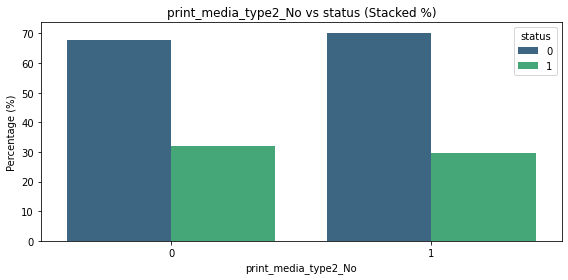


Frequency Table for 'print_media_type2_Yes' vs 'status':



status,0,1
print_media_type2_Yes,,
0,3065,1300
1,158,75



Percentage Table for 'print_media_type2_Yes' vs 'status':



status,0,1
print_media_type2_Yes,,
0,70.22,29.78
1,67.81,32.19


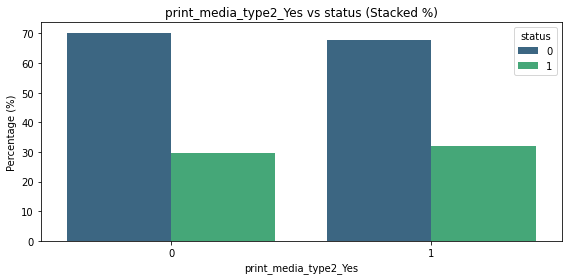


Frequency Table for 'digital_media_No' vs 'status':



status,0,1
digital_media_No,,
0,359,168
1,2864,1207



Percentage Table for 'digital_media_No' vs 'status':



status,0,1
digital_media_No,,
0,68.12,31.88
1,70.35,29.65


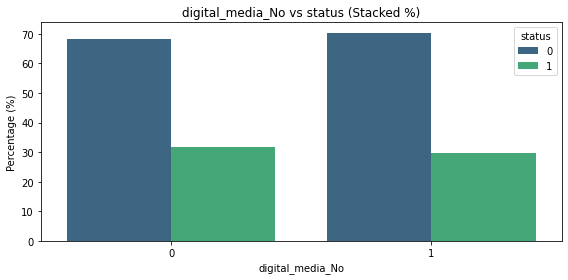


Frequency Table for 'digital_media_Yes' vs 'status':



status,0,1
digital_media_Yes,,
0,2864,1207
1,359,168



Percentage Table for 'digital_media_Yes' vs 'status':



status,0,1
digital_media_Yes,,
0,70.35,29.65
1,68.12,31.88


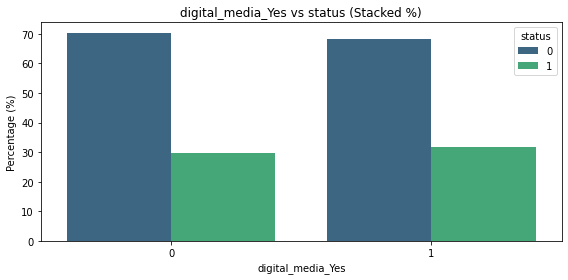


Frequency Table for 'educational_channels_No' vs 'status':



status,0,1
educational_channels_No,,
0,507,197
1,2716,1178



Percentage Table for 'educational_channels_No' vs 'status':



status,0,1
educational_channels_No,,
0,72.02,27.98
1,69.75,30.25


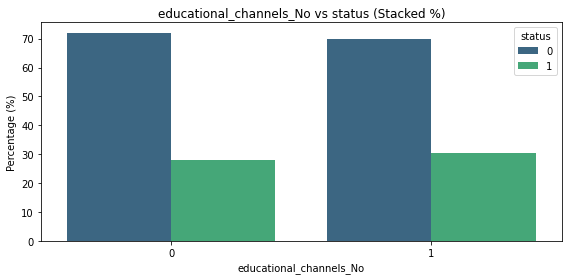


Frequency Table for 'educational_channels_Yes' vs 'status':



status,0,1
educational_channels_Yes,,
0,2716,1178
1,507,197



Percentage Table for 'educational_channels_Yes' vs 'status':



status,0,1
educational_channels_Yes,,
0,69.75,30.25
1,72.02,27.98


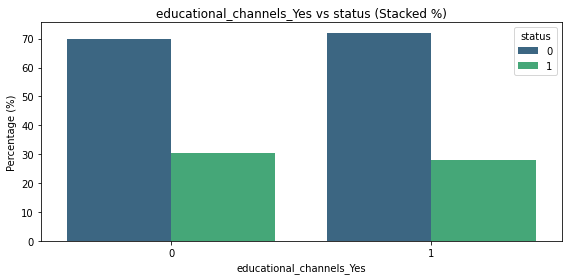


Frequency Table for 'referral_No' vs 'status':



status,0,1
referral_No,,
0,30,63
1,3193,1312



Percentage Table for 'referral_No' vs 'status':



status,0,1
referral_No,,
0,32.26,67.74
1,70.88,29.12


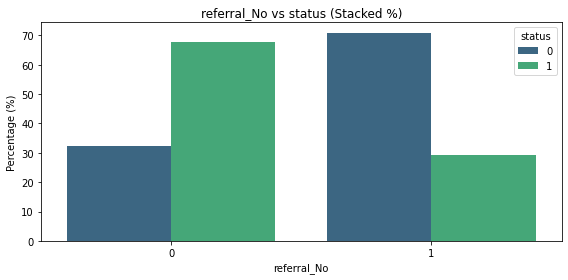


Frequency Table for 'referral_Yes' vs 'status':



status,0,1
referral_Yes,,
0,3193,1312
1,30,63



Percentage Table for 'referral_Yes' vs 'status':



status,0,1
referral_Yes,,
0,70.88,29.12
1,32.26,67.74


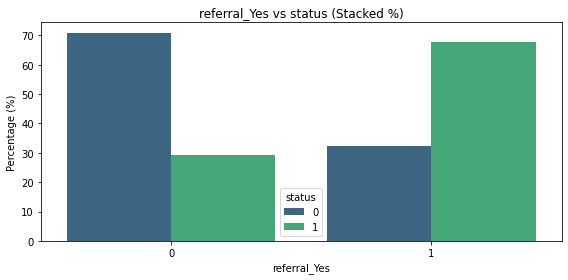

In [30]:
for col in cat_cols:
    stacked_barplot(df_encoded, col, "status")


Starting with current occupation, professionals show the highest conversion rate (35.54%) compared to students (11.73%) and unemployed users (26.67%). This suggests that professionals are more likely to convert.

Looking at first interaction channel, when the first contact occurs through the mobile app, conversion is only 10.57%, while for users whose first contact is via the website, conversion jumps to 45.62%. This indicates that website visitors are more engaged or informed.

Regarding profile completion, users with high or medium profile completeness show substantially higher conversion rates (41.86% and 40.30%) compared to those with low completeness (7.48%). This pattern reinforces the notion that user engagement within the platform, as reflected by the effort to complete their profile, is closely tied to conversion probability.

When analyzing last recorded activity, conversion rates are relatively similar across categories, but website activity shows a slight advantage (38.45%) over email (30.41%) and phone (21.32%).

In terms of lead acquisition channels, most mediums (print and digital) yield comparable conversion rates around 30–32%, with two exceptions:

- Educational channels have a slightly lower conversion (27.98%).
- Referrals stand out as the most effective channel (67.74% conversion).

In summary, based on the analysis, the factors most strongly associated with status = 1 (conversion) are: being a professional, starting interaction via the website, maintaining a medium or high profile completeness level, and coming through referrals.

# Train-Test Split

In [31]:
df_encoded = pd.get_dummies(df.drop(columns=['ID']), drop_first=True)
df_encoded = df_encoded.drop_duplicates()

Dropping the first dummy column for each categorical feature prevents perfect multicollinearity, which can destabilize regression-based models. Furthermore, for a Decision Tree, using N-1 dummy variables is generally sufficient as the removed column's information is redundant and implied; a value of 0 across all remaining N-1 dummies naturally indicates the baseline (or dropped) category.

In [32]:
df_encoded.shape

(4598, 17)

In [33]:
# Train-test split
X = df_encoded.drop('status', axis=1)
y = df_encoded['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3218, 16)
Test shape: (1380, 16)


The data is split into training and testing sets to evaluate the model's performance on unseen data, thereby assessing its ability to generalize rather than just memorize the training examples (preventing overfitting). Using test_size=0.30 reserves 30% of the data for an unbiased final evaluation, while stratify=y ensures that the proportion of the target variable (status) is maintained equally in both the training and testing sets, which is important for balanced model assessment.

In [34]:
#Plots the TOP N most importante features of the tree
def plot_feature_importances(model, X_train, top_n=15, title_prefix="Model"):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    feature_names = [X_train.columns[i] for i in indices]
    
    top_importances = importances[indices][:top_n]
    top_names = feature_names[:top_n]

    df_importances = pd.DataFrame({
        'Feature': top_names,
        'Importance Score': top_importances
    })
    
    print(f"Top {top_n} Feature Importances - {title_prefix} ")
    print(df_importances)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_importances, y=top_names)
    plt.title(f"Top {top_n} Most Important Features - {title_prefix}")
    plt.xlabel("Feature Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

In [35]:
#Plots a tree schema
def plot_single_tree(model, X_train, class_names=None, tree_index=0, max_depth=3, title_prefix="Model Tree", figsize=(28, 16)):

  if hasattr(model, "estimators_"):
    tree = model.estimators_[tree_index]
    model_name = model.__class__.__name__
    tree_label = f"{title_prefix}: {model_name} - Tree #{tree_index} (depth={max_depth})"
  else:
    tree = model
    tree_label = f"{title_prefix}: Depth={max_depth}"

  plt.figure(figsize=figsize)

  plot_tree(tree, max_depth=max_depth, feature_names=X_train.columns, class_names=class_names, filled=True, rounded=True, fontsize=10, node_ids=True, precision=2, label='root')
  plt.title(tree_label, fontsize=14)
  plt.tight_layout()
  plt.show()


## Building a Decision Tree model

In [36]:
#Decision Tree base model
dt_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=1,
    class_weight='balanced'
)
dt_model.fit(X_train, y_train)

#Predictions
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Performance:
Accuracy: 0.7956521739130434

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.85       967
           1       0.66      0.67      0.66       413

    accuracy                           0.80      1380
   macro avg       0.76      0.76      0.76      1380
weighted avg       0.80      0.80      0.80      1380


Confusion Matrix:
 [[823 144]
 [138 275]]


The Decision Tree model achieves an overall accuracy of approximately 79%, which initially appears solid. However, given the imbalance in the dataset, this metric does not fully reflect the model’s true performance. The classifier performs considerably better for the majority class (non-converted users), with strong precision and recall values, indicating that it can reliably identify users who are unlikely to convert. In contrast, performance noticeably drops for the minority class (converted users), where the model struggles to both correctly identify true converters and avoid false alarms. This misclassification pattern is reflected in the confusion matrix, showing a meaningful number of false negatives—users who would actually convert but are predicted as non-converting—which can represent a directly lost business opportunity. Therefore, despite reasonable global results, the model still demonstrates bias toward the dominant class and does not yet provide sufficiently strong predictive behavior for the conversions category.

Top 15 Feature Importances - Decision Tree 
                           Feature  Importance Score
0            time_spent_on_website          0.271448
1        first_interaction_Website          0.181730
2         profile_completed_Medium          0.144244
3             page_views_per_visit          0.121929
4                              age          0.100814
5                   website_visits          0.049687
6   last_activity_Website Activity          0.030999
7    current_occupation_Unemployed          0.023017
8     last_activity_Phone Activity          0.021711
9         educational_channels_Yes          0.015894
10           profile_completed_Low          0.013835
11                    referral_Yes          0.008561
12           print_media_type1_Yes          0.006342
13               digital_media_Yes          0.004497
14           print_media_type2_Yes          0.004048


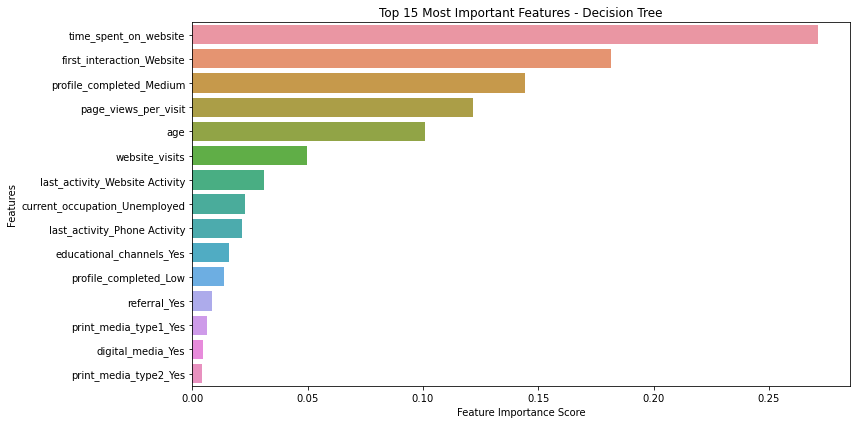

In [ ]:
#Feature Importance
plot_feature_importances(dt_model, X_train, top_n=15, title_prefix="Decision Tree")

The model emphasizes that engagement, measured through time on site, initial interaction, and profile completeness, is the most critical determinant of user status, while demographic or channel-related factors play a secondary role.

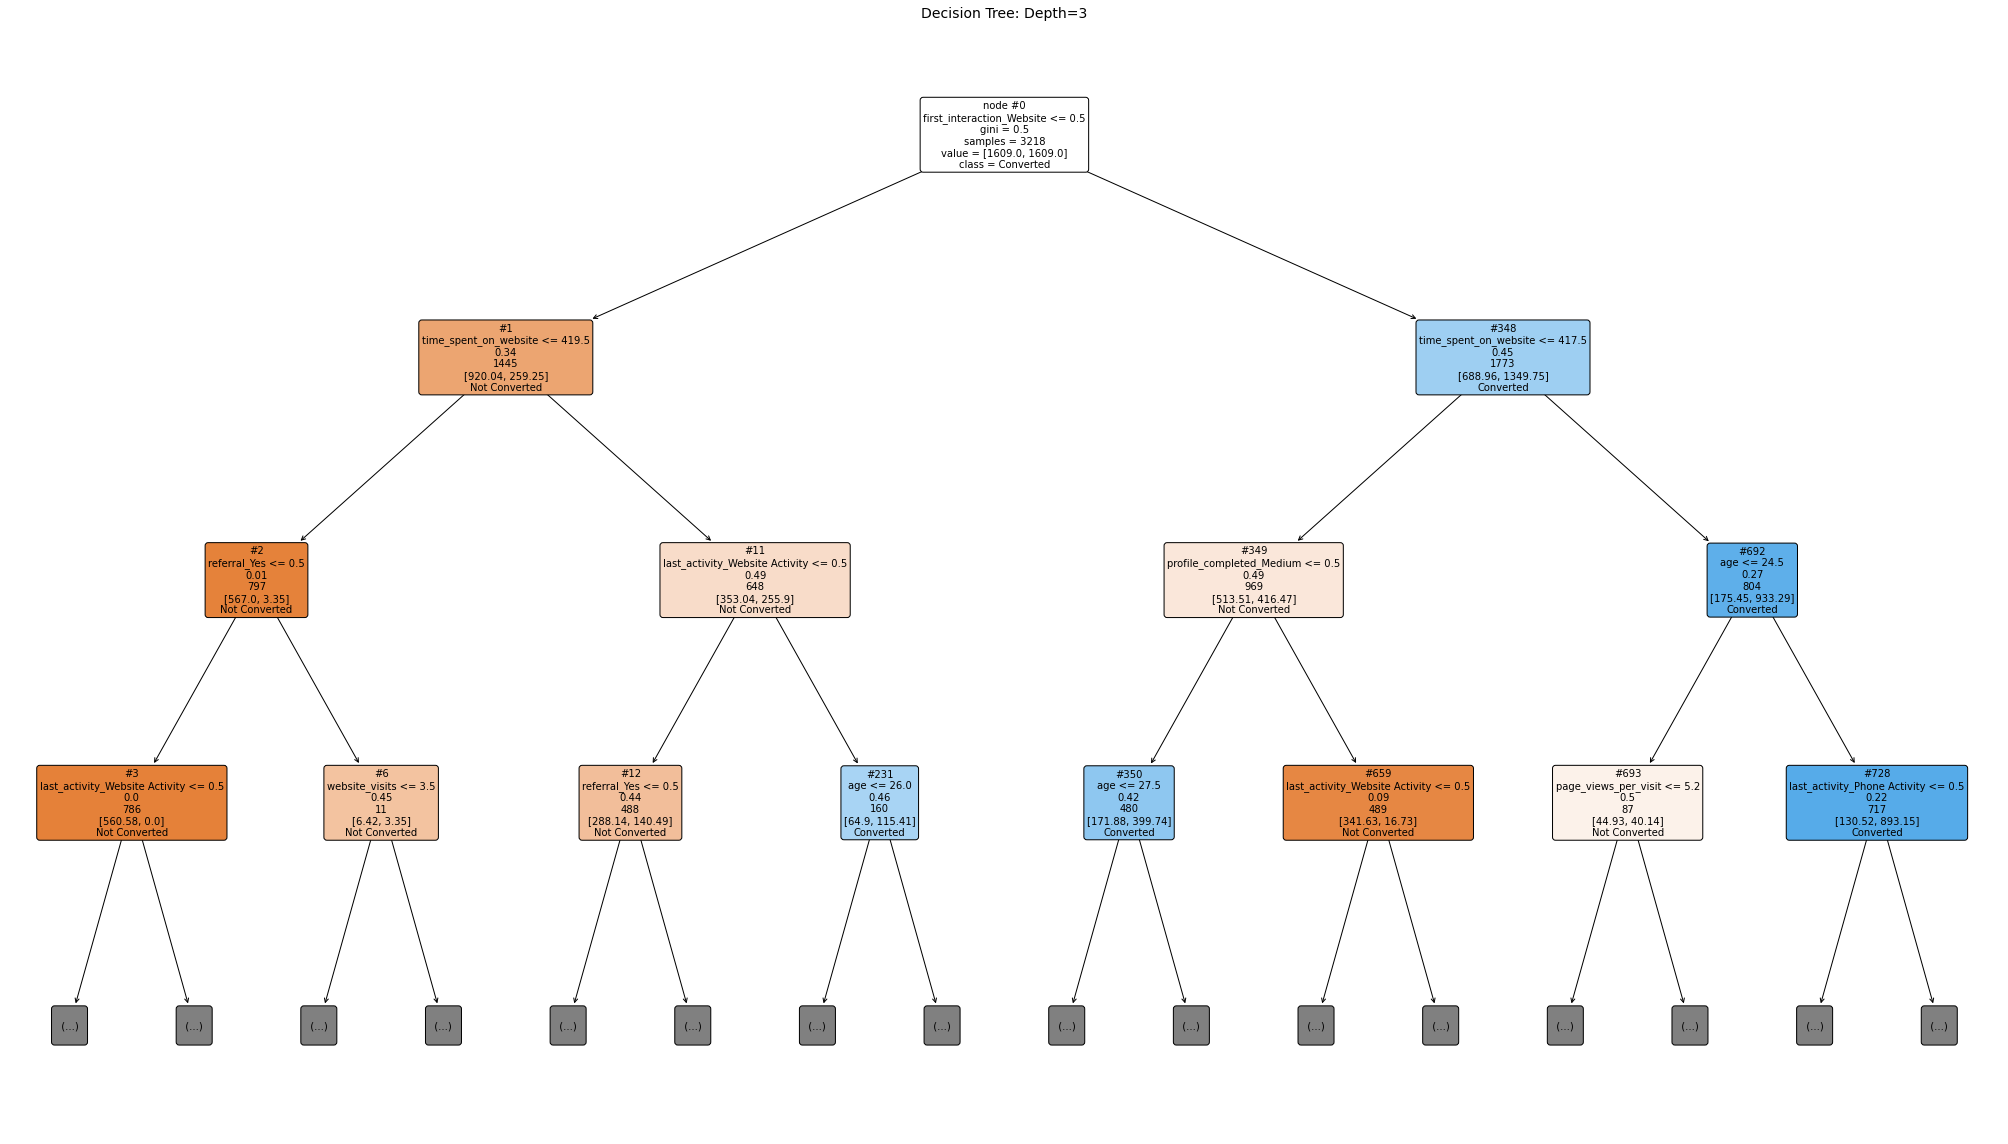

In [38]:
plot_single_tree(
    model=dt_model,
    X_train=X_train,
    class_names=['Not Converted', 'Converted'],
    max_depth=3,
    title_prefix="Decision Tree"
)

## Do we need to prune the tree?

To determine whether the decision tree is overfitting and requires pruning, we first evaluate the unpruned model on both the training and test sets. If the model performs significantly better on the training set than on the test set, this would indicate overfitting and justify the need for pruning.

In [39]:
dt_base = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_base.fit(X_train, y_train)
y_train_pred = dt_base.predict(X_train)
y_test_pred = dt_base.predict(X_test)
y_proba_base = dt_base.predict_proba(X_test)[:,1]
print("Train accuracy (base):", accuracy_score(y_train, y_train_pred))
print("Test accuracy (base):", accuracy_score(y_test, y_test_pred))
print("Tree ROC AUC (base):", roc_auc_score(y_test, y_proba_base))
print("Train classification report:")
print(classification_report(y_train, y_train_pred))
print("Test classification report:")
print(classification_report(y_test, y_test_pred))

Train accuracy (base): 0.9996892479801118
Test accuracy (base): 0.7956521739130434
Tree ROC AUC (base): 0.7584726983181053
Train classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2256
           1       1.00      1.00      1.00       962

    accuracy                           1.00      3218
   macro avg       1.00      1.00      1.00      3218
weighted avg       1.00      1.00      1.00      3218

Test classification report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       967
           1       0.66      0.67      0.66       413

    accuracy                           0.80      1380
   macro avg       0.76      0.76      0.76      1380
weighted avg       0.80      0.80      0.80      1380



Based on this analysis, pruning is required. The unpruned tree achieves nearly perfect accuracy on the training set (almost 100%) while dropping to around 79% on the test set, indicating overfitting. This means the tree is memorizing training patterns instead of learning generalizable decision rules. The model is especially weak at identifying converted users (class 1), resulting in a high number of false negatives (lost conversion opportunities).

Next, we evaluate a range of ccp_alpha values using cross-validation to identify the pruning level that maximizes generalization performance.

In [40]:
dt_for_path = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_for_path.fit(X_train, y_train)

path = dt_for_path.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print("Alpha numbers:", len(ccp_alphas))

Alpha numbers: 242


The tree has 242 possible pruning levels, meaning there are 242 different subtrees that the algorithm can consider.

In [41]:
alpha_results = []
for ccp in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=1, class_weight='balanced', ccp_alpha=ccp)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='roc_auc')
    alpha_results.append((ccp, scores.mean(), scores.std()))

alpha_df = pd.DataFrame(alpha_results, columns=['ccp_alpha','mean_rocauc','std'])
alpha_df = alpha_df.sort_values('ccp_alpha').reset_index(drop=True)

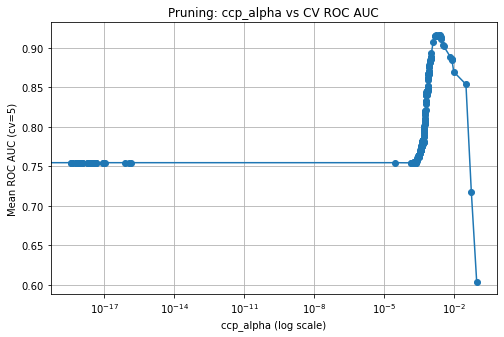

In [42]:
#Alpha vs mean ROC AUC
plt.figure(figsize=(8,5))
plt.plot(alpha_df['ccp_alpha'], alpha_df['mean_rocauc'], marker='o')
plt.xscale('log')
plt.xlabel('ccp_alpha (log scale)')
plt.ylabel('Mean ROC AUC (cv=5)')
plt.title('Pruning: ccp_alpha vs CV ROC AUC')
plt.grid(True)
plt.show()

In [43]:
best_row = alpha_df.loc[alpha_df['mean_rocauc'].idxmax()]
best_alpha = float(best_row['ccp_alpha'])
print("Best alpha (max mean_rocauc):", best_alpha, "with mean ROC AUC:", best_row['mean_rocauc'])

dt_pruned = DecisionTreeClassifier(random_state=42, class_weight='balanced', ccp_alpha=best_alpha)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
y_proba_pruned = dt_pruned.predict_proba(X_test)[:,1]

print("\nPruned Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_pruned))
print("ROC AUC:", roc_auc_score(y_test, y_proba_pruned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_pruned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_pruned))

Best alpha (max mean_rocauc): 0.002371319295177015 with mean ROC AUC: 0.9168196173181213

Pruned Tree Performance:
Accuracy: 0.8282608695652174
ROC AUC: 0.9200630491447801

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87       967
           1       0.67      0.85      0.75       413

    accuracy                           0.83      1380
   macro avg       0.80      0.83      0.81      1380
weighted avg       0.85      0.83      0.83      1380


Confusion Matrix:
 [[793 174]
 [ 63 350]]


After applying cost-complexity pruning and selecting the optimal ccp_alpha through cross-validation, the pruned tree improves both performance and generalization capacity. Test accuracy increases to approximately 83%, and more importantly, ROC AUC rises to 0.91, which means an improvement in the model’s ability to distinguish between converters and non-converters. Additionally, recall for the conversion class increases from 0.67 to 0.85, making the pruned model far more valuable from a marketing perspective.

Top 15 Feature Importances - Pruned Decision Tree 
                           Feature  Importance Score
0        first_interaction_Website          0.318488
1            time_spent_on_website          0.281308
2         profile_completed_Medium          0.238117
3                              age          0.060738
4   last_activity_Website Activity          0.039589
5    current_occupation_Unemployed          0.023945
6     last_activity_Phone Activity          0.020490
7            profile_completed_Low          0.009009
8             page_views_per_visit          0.008317
9                     referral_Yes          0.000000
10        educational_channels_Yes          0.000000
11               digital_media_Yes          0.000000
12           print_media_type2_Yes          0.000000
13           print_media_type1_Yes          0.000000
14      current_occupation_Student          0.000000


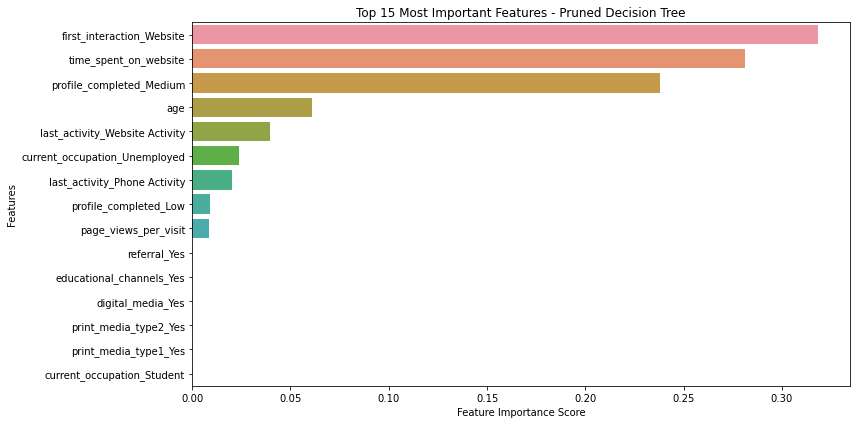

In [44]:
#Feature Importance
plot_feature_importances(dt_pruned, X_train, top_n=15, title_prefix="Pruned Decision Tree")


The optimized, pruned decision tree identifies early and deep engagement as the primary driver of user status, with the initial website interaction, time spent on the website, and medium profile completion collectively contributing over 83% of the model's predictive power. Secondary and relatively minor influences include age and the last activity being on the website, while factors related to media channels, specific occupations, and referrals demonstrate negligible predictive utility for this classification task.

In [45]:
y_proba_base = dt_base.predict_proba(X_test)[:,1]
print("\nBase Tree ROC AUC:", roc_auc_score(y_test, y_proba_base))
print("Pruned Tree ROC AUC:", roc_auc_score(y_test, y_proba_pruned))


Base Tree ROC AUC: 0.7584726983181053
Pruned Tree ROC AUC: 0.9200630491447801


The optimization process yielded a highly effective model, with the Pruned Decision Tree achieving a 0.920 ROC AUC score, representing a significant 16.2% improvement over the Base Tree's score of 0.758. This outcome confirms that cost complexity pruning successfully mitigated the overfitting inherent in the fully grown tree, resulting in a model with superior generalization capability.

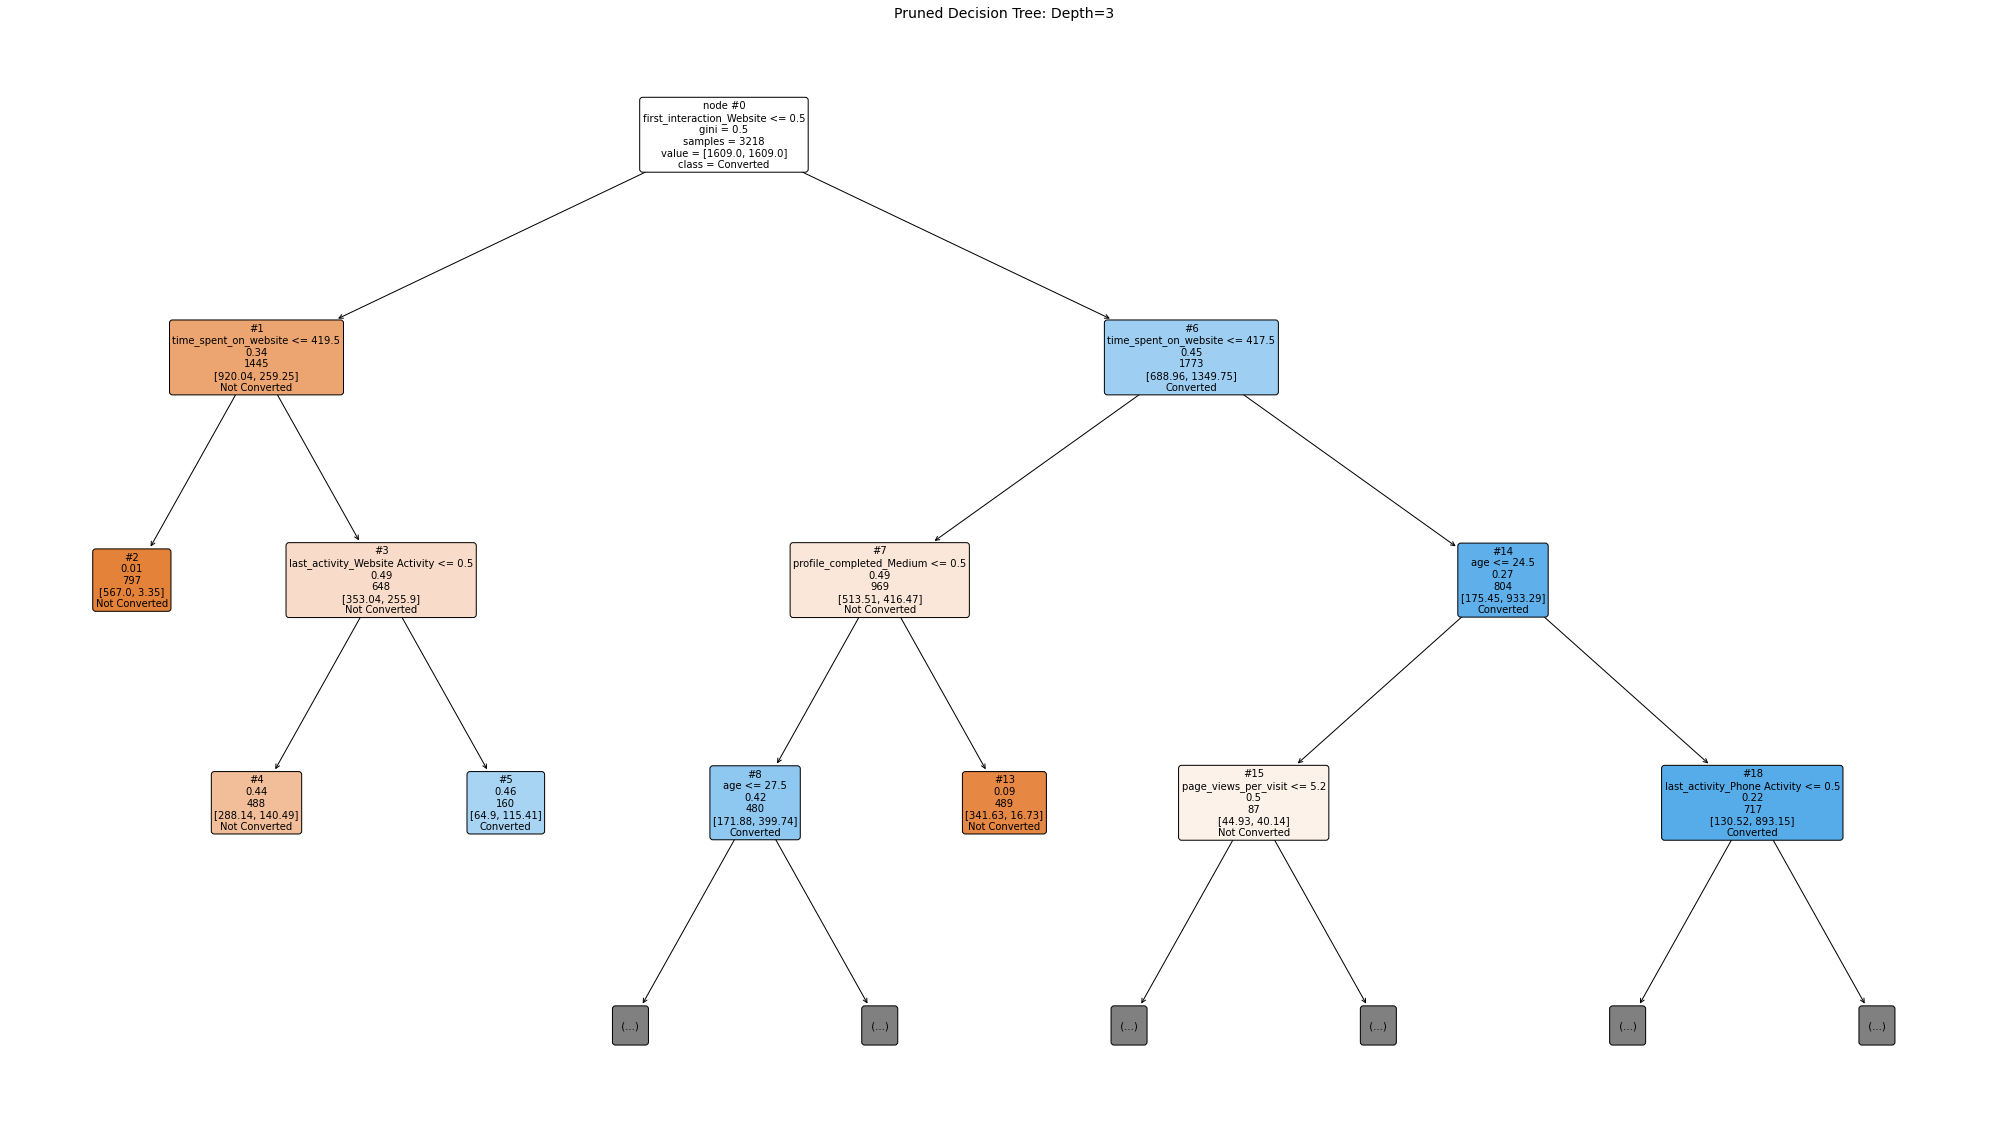

In [46]:
plot_single_tree(
    model=dt_pruned,
    X_train=X_train,
    class_names=['Not Converted', 'Converted'],
    max_depth=3,
    title_prefix="Pruned Decision Tree"
)


### Tuned Tree

In [47]:
#Hyperparameter tuning with GridSearchCV
param_grid = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Mean ROC AUC (CV):", grid_search.best_score_)

best_dt = grid_search.best_estimator_


Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best Mean ROC AUC (CV): 0.9095812804522418


The process carried out with GridSearchCV shows that the best set of parameters obtained was: class_weight = ‘balanced’, criterion = ‘gini’, max_depth = 5, min_samples_leaf = 10, and min_samples_split = 2. With this configuration, the model achieved an average ROC-AUC score of 0.9096 in cross-validation.

These results reflect a more controlled and generalizable decision tree. Limiting the depth to five levels reduces the risk of overfitting, while requiring a minimum of 2 samples to split a node prevents non-informative splits. The Gini criterion proved to be more effective than entropy for this dataset, and including the class_weight=‘balanced’ parameter improved performance in the presence of class imbalance.

In [48]:
y_pred_tuned = best_dt.predict(X_test)
y_proba_tuned = best_dt.predict_proba(X_test)[:,1]

print("\nTuned Decision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("ROC AUC:", roc_auc_score(y_test, y_proba_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))



Tuned Decision Tree Performance:
Accuracy: 0.8376811594202899
ROC AUC: 0.9211622776816544

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.82      0.88       967
           1       0.67      0.88      0.77       413

    accuracy                           0.84      1380
   macro avg       0.81      0.85      0.82      1380
weighted avg       0.86      0.84      0.84      1380


Confusion Matrix:
 [[791 176]
 [ 48 365]]


The tuned decision tree demonstrates a balanced performance. With an overall accuracy of 83.8% and a ROC AUC of 0.92, the model shows great ability to distinguish between the two classes, indicating strong predictive power and good generalization. Additionally, the model prioritizes identifying positive cases, achieving a high recall for class 1. This means it effectively detects most relevant instances, even though it produces some false positives, which may be acceptable if the main goal is to avoid missing potential opportunities. Compared to the initial tree, the tuned model achieves a better balance between precision and sensitivity, reducing the risk of overfitting while maintaining a simpler and more interpretable structure.

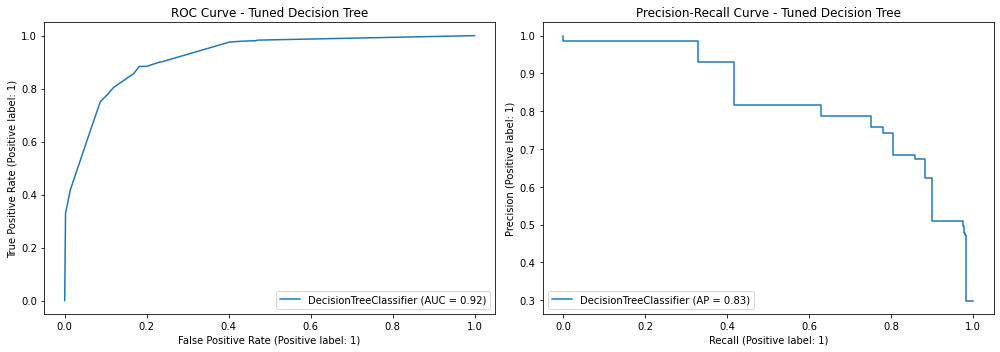

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(best_dt, X_test, y_test, ax=axs[0])
axs[0].set_title("ROC Curve - Tuned Decision Tree")

PrecisionRecallDisplay.from_estimator(best_dt, X_test, y_test, ax=axs[1])
axs[1].set_title("Precision-Recall Curve - Tuned Decision Tree")

plt.tight_layout()
plt.show()

Top 15 Feature Importances - Tuned Decision Tree 
                           Feature  Importance Score
0        first_interaction_Website          0.314419
1            time_spent_on_website          0.279587
2         profile_completed_Medium          0.234410
3                              age          0.069656
4   last_activity_Website Activity          0.032328
5    current_occupation_Unemployed          0.026142
6     last_activity_Phone Activity          0.025466
7                     referral_Yes          0.009782
8             page_views_per_visit          0.008211
9         educational_channels_Yes          0.000000
10               digital_media_Yes          0.000000
11           print_media_type2_Yes          0.000000
12           print_media_type1_Yes          0.000000
13           profile_completed_Low          0.000000
14      current_occupation_Student          0.000000


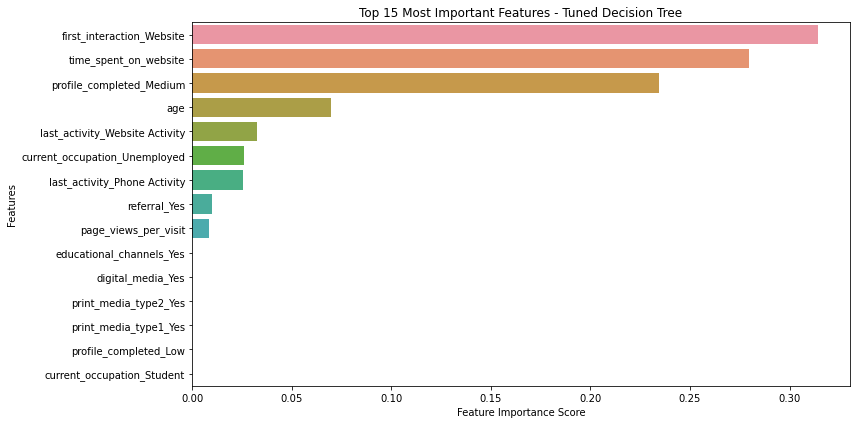

In [50]:
plot_feature_importances(best_dt, X_train, top_n=15, title_prefix="Tuned Decision Tree")

## Building a Random Forest model

In [51]:
#Random Forest base model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=1,
    class_weight='balanced',
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf_base = rf_model.predict_proba(X_test)[:, 1]

#Performance evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf_base))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.855072463768116
ROC AUC: 0.9153281034426636

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       967
           1       0.79      0.71      0.75       413

    accuracy                           0.86      1380
   macro avg       0.83      0.81      0.82      1380
weighted avg       0.85      0.86      0.85      1380


Confusion Matrix:
 [[887  80]
 [120 293]]


The Random Forest model demonstrates solid predictive performance and a balanced ability to classify both user groups. The confusion matrix indicates that the model correctly identifies most non-converted users (887) while keeping the number of false positives relatively low (80). It also shows a strong capacity to detect converted users, with 293 correct predictions, though some cases are still misclassified as non-converted (120 false negatives). These results suggest that the model effectively captures relevant patterns in the data, achieving a good trade-off between precision and recall.

Top 15 Feature Importances - Random Forest 
                           Feature  Importance Score
0            time_spent_on_website          0.278759
1        first_interaction_Website          0.184869
2             page_views_per_visit          0.110241
3         profile_completed_Medium          0.106742
4                              age          0.100760
5                   website_visits          0.060545
6     last_activity_Phone Activity          0.028574
7   last_activity_Website Activity          0.024735
8    current_occupation_Unemployed          0.023622
9       current_occupation_Student          0.018249
10           profile_completed_Low          0.012967
11        educational_channels_Yes          0.012125
12               digital_media_Yes          0.010921
13           print_media_type1_Yes          0.010846
14                    referral_Yes          0.008835


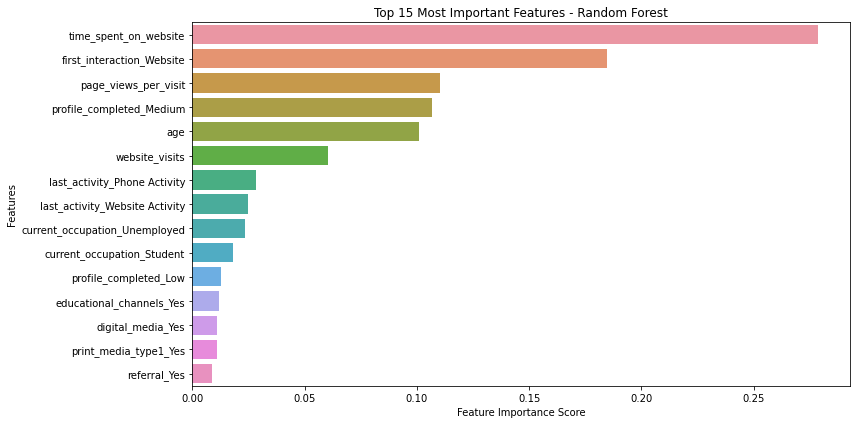

In [ ]:
#Feature Importance
plot_feature_importances(rf_model, X_train, top_n=15, title_prefix="Random Forest")

The Random Forest model shows that time spent on website is the most crucial predictor. It distributes significant predictive weight across a broader set of variables, including first interaction, age and page views per visit, indicating that user status is determined by a wider combination of engagement and demographic factors.

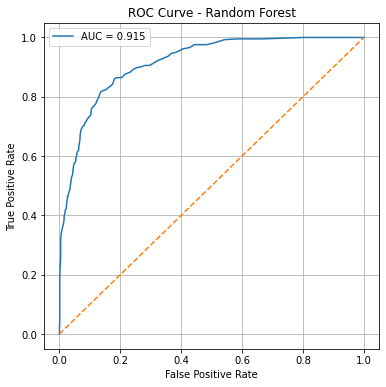

In [53]:
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
auc = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], linestyle='--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


The AUC value of 0.915 shows that the Random Forest model exhibits great predictive performance on unseen data. When compared to the Pruned Decision Tree's ROC AUC of 0.920, the Random Forest is only marginally less effective, demonstrating highly similar and robust classification capabilities. This outcome is meaningful because it indicates that the ensemble model, while slightly lower in this specific metric, provides a strong, reliable alternative, especially given the inherent stability and reduced risk of overfitting typically associated with Random Forest classifiers. The similarity in scores suggests that both the optimal pruning process and the ensemble method successfully capture the core predictive patterns in the data.

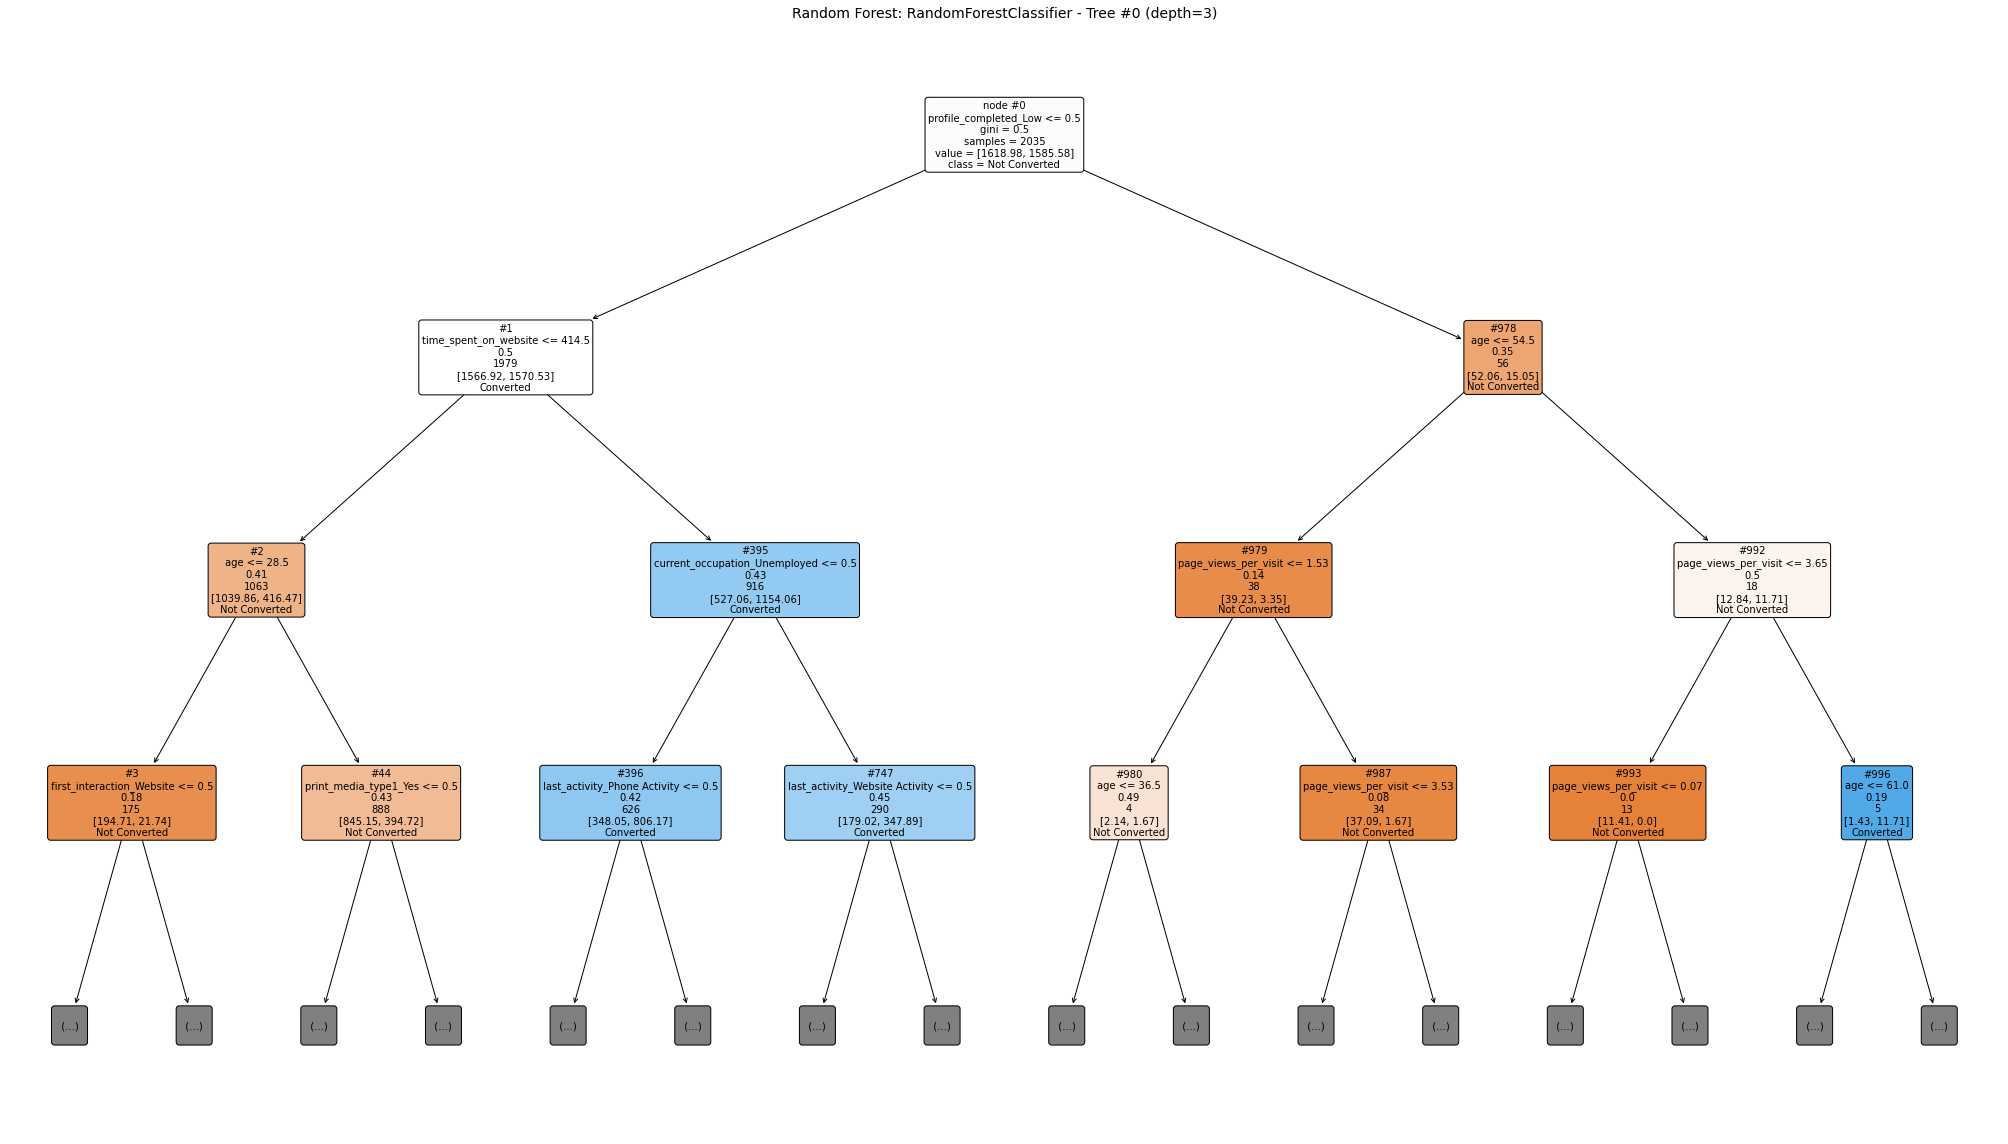

In [54]:
plot_single_tree(
  model=rf_model,
  X_train=X_train,
  class_names=['Not Converted', 'Converted'],
  tree_index=0,
  max_depth=3,
  title_prefix="Random Forest"
)

## Do we need to prune the tree?

Unlike a Decision Tree, a Random Forest does not require explicit pruning. The ensemble technique (bagging + feature randomness) already reduces the risk of overfitting. Instead of pruning, we tune hyperparameters such as max_depth, min_samples_leaf, and n_estimators to further improve generalization and model performance.

### Tuned Tree

In [55]:
#Hyperparameter tuning with GridSearchCV (Random Forest parameters)
param_grid_rf = {
  "n_estimators": [50, 100, 200],
  "max_features": ['sqrt', 0.5, 0.7],
  "max_depth": [None, 10, 20],
  "min_samples_split": [5, 10, 20],
  "min_samples_leaf": [2, 5],
  "class_weight": ["balanced"]
}

grid_search_rf = GridSearchCV(
  estimator=RandomForestClassifier(random_state=1, n_jobs=-1),
  param_grid=param_grid_rf,
  scoring="roc_auc",
  cv=5,
  n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_

print("Best Parameters:", grid_search_rf.best_params_)
print("Best Mean ROC AUC (CV):", grid_search_rf.best_score_)

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 200}
Best Mean ROC AUC (CV): 0.9254700703653167


In [56]:
y_pred_tuned_rf = best_rf.predict(X_test)
y_proba_tuned_rf = best_rf.predict_proba(X_test)[:, 1]

print("\nTuned Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_tuned_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned_rf))


Tuned Random Forest Performance
Accuracy: 0.8463768115942029
ROC AUC: 0.9286152474766571

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.85      0.89       967
           1       0.70      0.84      0.77       413

    accuracy                           0.85      1380
   macro avg       0.81      0.84      0.83      1380
weighted avg       0.86      0.85      0.85      1380


Confusion Matrix:
 [[821 146]
 [ 66 347]]


The tuned Random Forest presents a slightly different performance profile compared to the baseline model. While the overall accuracy remains relatively stable (84.6% versus 85.5%), the tuned version achieves a higher ROC AUC of 0.929, indicating improved discrimination between the two classes. The tuning process shifted the model’s focus toward better recall for class 1 (0.84 compared to 0.71), meaning it now captures a larger proportion of true positive cases. This improvement comes at the cost of a modest reduction in precision for the same class, reflecting a trade-off that favors identifying more relevant instances even if a few additional false positives occur. The confusion matrix shows fewer false negatives but a higher number of false positives.

## Actionable Insights and Recommendations

Based on the analysis, it is possible to say that conversion is primarily driven by behavioral engagement rather than static demographic profiles. The most significant predictors are the recency and intensity of a user's interactions, particularly website visits, email engagement, and prior purchase history. Customers who initiate their journey on the website and maintain frequent engagement are substantially more likely to convert. This indicates that active consideration and demonstrated interest are the most reliable indicators of purchase intent.

To capitalize on the key behaviors and characteristics linked to higher conversion, we recommend the following coordinated initiatives:

- Strengthen digital acquisition via website-first journeys: Focus marketing budget and SEO efforts on channels that drive users directly to the website. Optimize landing pages and initial calls-to-action to ensure that new visitors quickly engage with relevant content. This approach maximizes the value of the strongest observed conversion trigger: website as the first interaction point.

- Enhance and personalize on-site engagement: Introduce guided navigation, dynamic content, tailored recommendations, and interactive tools that keep visitors exploring longer and deepen their interest. Prioritize the experiences that led high-value customers to convert.

- Activate and accelerate warm leads through targeted supporting: Users with partially completed profiles or recent engagement exhibit strong intent. Deploy automated, personalized reminders, incentives, and educational nudges to encourage these users to finalize onboarding before they lapse.

- Implement real-time proactive support for highly engaged visitors: Make use of monitor behavioral signals such as time on site and number of pages viewed to trigger live chat invitations, tailored offers, or priority outreach at the right moment.

- Optimize segmentation and lead prioritization: Refine lead scoring within the CRM using behavioral and demographic indicators that most strongly correlate with conversion. Direct sales and marketing resources first toward audiences with the highest propensity to convert, which reduces operational waste.

- Allocate media spend based on engagement-driven performance: Shift investment toward channels and content that generate deeper engagement behaviors, not just traffic volume.

- Maintain retention and reactivation focus for recent users: Build automated re-engagement campaigns to prevent high-intent prospects from lapsing. Timely outreach via email or push notifications can recover a significant number of potential customers who have paused before converting.